# Zenodo v2 — OT-CFM
**Architecture:** 4-level U-Net · base_ch=64 · AdaGN conditioning · Heun sampler  
**Conditioning (B2):** IBI_mean · IBI_std · RMSSD · rhythm label (AF=+1, SR=−1)  
**IBI source:** ECG gold standard (QRSindex + rr arrays from HDF5)  
**Pipeline:** mirrors MIMIC-III-Ext-PPG CFM — same evaluation framework

---
- §0 Setup  
- §1 Subject splits (Cat A / Cat B)  
- §2 Dataset assembly — segmentation · ECG features · PPG loading  
- §3 IBI/RMSSD normalisation + statistics  
- §4 PPGDataset & DataLoaders  
- §5 Model — UNet1D with AdaGN  
- §6 Training — CFM loss · EMA · AMP · 40 epochs  
- §7 Guidance scale sweep + visual generation  
- §8 Spectral evaluation (PSD + LSD 0.5–8 Hz)  
- §9 Physiological consistency (HR · IBI · RMSSD)  
- §10 Statistical validation and additional testes  
- §11 Functional evaluation (Clf1D, ClfUNetGAN)  
- §12 Functional Cross-Domain validation (PartB,C and D)
- §13 Data Scarcity (Clf1D and ClfUNetGAN)


## §0 — Setup

In [1]:
import os, warnings, random, time, copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.signal import butter, filtfilt, welch, find_peaks, resample_poly
from scipy.stats import wasserstein_distance
from sklearn.manifold import TSNE
from sklearn.metrics import roc_auc_score, precision_score, f1_score
from sklearn.preprocessing import StandardScaler
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 0   # same as best Zenodo v2 split found in exploration
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# ── Device — single GPU + AMP ────────────────────────────────────────────────
DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()
scaler  = torch.cuda.amp.GradScaler(
    enabled=USE_AMP, init_scale=128,
    growth_factor=2.0, backoff_factor=0.5, growth_interval=1000)
torch.backends.cudnn.benchmark = True
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"AMP    : {'float16 (init_scale=128)' if USE_AMP else 'float32'}")

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR  = Path("/kaggle/input/datasets/vegatronxz/zenodo-v2/zenodo_v2")
WORK_DIR  = Path("/kaggle/working")
CKPT_PATH = WORK_DIR / "best_cfm_b2_zenodo.pt"
WORK_DIR.mkdir(exist_ok=True)

# ── Signal constants ─────────────────────────────────────────────────────────
ECG_FS      = 500          # Hz — Bittium Faros ECG
PPG_FS_RAW  = 100          # Hz — wrist PPG (original)
FS          = 125          # Hz — target after resampling (= MIMIC standard)
WIN_SEC     = 10           # seconds
WIN_LEN     = FS * WIN_SEC # 1250 samples
PAD_LEN     = (256 - WIN_LEN % 256) % 256   # 30 → padded to 1280 (= 5×256)
WIN_LEN_PAD = WIN_LEN + PAD_LEN             # 1280

# ── Conditioning constants (B2) ───────────────────────────────────────────────
RAW_COND_DIM = 4     # [IBI_mean_norm, IBI_std_norm, RMSSD_norm, rhythm_sign]
RHYTHM_SIGN  = {'AF': +1.0, 'SR': -1.0}

# ── Physiological plausibility filters ───────────────────────────────────────
IBI_MIN = 0.30   # seconds (= 200 bpm upper HR bound)
IBI_MAX = 2.00   # seconds (= 30  bpm lower HR bound)

# ── Model hyperparameters ─────────────────────────────────────────────────────
BASE_CH  = 64
T_DIM    = 256
COND_DIM = 128

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE = 256
LR         = 1e-4
WEIGHT_DECAY = 1e-3
EPOCHS     = 80
EMA_DECAY  = 0.999
CFG_DROP   = 0.10    # classifier-free guidance dropout prob
CAP        = 600#2000    # max windows per (subject, class)

# ── Evaluation ────────────────────────────────────────────────────────────────
ODE_STEPS  = 100
N_EVAL     = 300     # synthetic + real samples per class
N_TSNE     = 200     # per group for t-SNE

print(f"WIN_LEN={WIN_LEN}  PAD={PAD_LEN}  →  model input={WIN_LEN_PAD}")
print(f"BASE_CH={BASE_CH}  RAW_COND_DIM={RAW_COND_DIM}  CAP={CAP}")
print(f"EPOCHS={EPOCHS}  ODE_STEPS={ODE_STEPS}  N_EVAL={N_EVAL}")


Device : cuda
GPU    : Tesla T4
AMP    : float16 (init_scale=128)
WIN_LEN=1250  PAD=30  →  model input=1280
BASE_CH=64  RAW_COND_DIM=4  CAP=600
EPOCHS=80  ODE_STEPS=100  N_EVAL=300


## §1 — Subject splits
**Excluded:** 028 (corrupted HDF5) · 029 (PPG unusable) · 042 (PPG unusable)  
**Cat A** — AF ≥ 200 windows → contributes both AF and SR windows  
**Cat B** — AF < 200 windows → contributes SR windows only  
Stratified 17/2/2 split within each category. SEED=0 chosen for balanced test coverage.


In [2]:
CAT_A = [1,2,4,6,8,11,12,17,18,19,20,21,23,27,32,34,37,41,43,44,45]  # 21 subjects
CAT_B = [3,5,7,9,10,13,14,15,16,22,24,25,26,30,31,33,35,36,38,39,40] # 21 subjects

random.seed(SEED)
cat_a = CAT_A.copy(); random.shuffle(cat_a)
cat_b = CAT_B.copy(); random.shuffle(cat_b)

TRAIN_A, VAL_A, TEST_A = cat_a[:17], cat_a[17:19], cat_a[19:]
TRAIN_B, VAL_B, TEST_B = cat_b[:17], cat_b[17:19], cat_b[19:]

TRAIN_SIDS = sorted(TRAIN_A + TRAIN_B)
VAL_SIDS   = sorted(VAL_A   + VAL_B)
TEST_SIDS  = sorted(TEST_A  + TEST_B)

print(f"TRAIN ({len(TRAIN_SIDS)}): {TRAIN_SIDS}")
print(f"  Cat A: {sorted(TRAIN_A)}")
print(f"  Cat B: {sorted(TRAIN_B)}")
print(f"VAL   ({len(VAL_SIDS)}):   {VAL_SIDS}")
print(f"  Cat A: {sorted(VAL_A)}  Cat B: {sorted(VAL_B)}")
print(f"TEST  ({len(TEST_SIDS)}):  {TEST_SIDS}")
print(f"  Cat A: {sorted(TEST_A)}  Cat B: {sorted(TEST_B)}")


TRAIN (34): [1, 3, 4, 5, 6, 8, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 25, 26, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 43, 44, 45]
  Cat A: [1, 4, 6, 8, 11, 12, 17, 19, 20, 21, 32, 34, 37, 41, 43, 44, 45]
  Cat B: [3, 5, 10, 13, 14, 15, 16, 25, 26, 30, 31, 33, 35, 36, 38, 39, 40]
VAL   (4):   [2, 7, 18, 24]
  Cat A: [2, 18]  Cat B: [7, 24]
TEST  (4):  [9, 22, 23, 27]
  Cat A: [23, 27]  Cat B: [9, 22]


## §2 — Dataset assembly
For each subject:
1. Load ECG HDF5 → QRS timestamps · AF annotations · RR intervals  
2. For each PPG segment → align to ECG timeline by absolute `t0_sec`  
3. Segment into 10s windows → label by majority AF beat vote  
4. Extract ECG-derived IBI_mean · IBI_std · RMSSD per window  
5. PPG quality filter (variance + finite check)  
6. Resample PPG 100 Hz → 125 Hz · min-max normalise to [−1, 1]  
7. Apply per-class cap = 2000 windows/subject  

Results cached to disk as `.npz` to avoid re-processing (≈ 5–6 h on first run).


In [3]:
# ── HDF5 helpers ─────────────────────────────────────────────────────────────
def ecg_path(sid): return DATA_DIR / f"{sid:03d}_ECG.mat"
def ppg_path(sid): return DATA_DIR / f"{sid:03d}_PPG.mat"

def decode_ascii(arr):
    try:
        return ''.join(chr(int(c)) for c in np.array(arr).flatten() if int(c) != 0).strip()
    except Exception:
        return ''

def timestamp_to_seconds(day_str, time_str):
    try:
        day   = int(day_str.strip()) if day_str.strip().isdigit() else 1
        parts = time_str.strip().split(':')
        h = int(parts[0]) if len(parts) > 0 else 0
        m = int(parts[1]) if len(parts) > 1 else 0
        s = int(parts[2]) if len(parts) > 2 else 0
        return (day - 1) * 86400 + h * 3600 + m * 60 + s
    except Exception:
        return None

def load_ecg(sid):
    with h5py.File(ecg_path(sid), 'r') as f:
        sig      = np.array(f['ECG']).squeeze().astype(np.float32)
        qrs      = np.array(f['QRSindex']).squeeze().astype(int)
        af       = np.array(f['AF_annotation']).squeeze().astype(int)
        rr       = np.array(f['rr']).squeeze().astype(np.float64)
        day_str  = decode_ascii(f['recording_startday'])
        time_str = decode_ascii(f['recording_starttime'])
    qrs = qrs[:len(af)]   # off-by-one fix: N beats, N-1 RR intervals
    t0  = timestamp_to_seconds(day_str, time_str)
    if t0 is None:
        raise ValueError(f"S{sid:03d}: invalid ECG timestamp")
    return dict(sig=sig, fs=ECG_FS, qrs=qrs, af=af, rr=rr, t0_sec=t0)

def load_ppg_segments(sid):
    segments = []
    with h5py.File(ppg_path(sid), 'r') as f:
        ppg_refs  = f['PPG_GREEN']
        day_refs  = f['recording_startday']
        time_refs = f['recording_starttime']
        for i in range(ppg_refs.shape[0]):
            sig      = np.array(f[ppg_refs[i,0]]).squeeze().astype(np.float32)
            day_str  = decode_ascii(f[day_refs[i,0]])
            time_str = decode_ascii(f[time_refs[i,0]])
            t0       = timestamp_to_seconds(day_str, time_str)
            if t0 is None:
                continue
            segments.append(dict(sig=sig, fs=PPG_FS_RAW, t0_sec=t0,
                                 n_samples=len(sig), seg_idx=i))
    return segments

# ── PPG preprocessing ─────────────────────────────────────────────────────────
_B4, _A4 = butter(4, [0.5/(PPG_FS_RAW/2), 8./(PPG_FS_RAW/2)], btype='band')
WIN_SAMP_RAW = WIN_SEC * PPG_FS_RAW  # 1000 samples at 100 Hz

def preprocess_ppg(win_raw):
    """Bandpass → resample 100→125 Hz → min-max [−1, 1]. Returns None if invalid."""
    if not np.all(np.isfinite(win_raw)) or np.all(win_raw == win_raw[0]):
        return None
    filt = filtfilt(_B4, _A4, win_raw.astype(float))
    if np.std(filt) < 1e-4:
        return None
    sig125 = resample_poly(filt, FS, PPG_FS_RAW)[:WIN_LEN]  # 100→125 Hz
    if len(sig125) < WIN_LEN:
        return None
    mn, mx = sig125.min(), sig125.max()
    if mx - mn < 1e-8:
        return None
    return (2*(sig125 - mn)/(mx - mn) - 1).astype(np.float32)

# ── ECG feature extraction per window ────────────────────────────────────────
def ecg_features_window(rr_window):
    """IBI_mean, IBI_std, RMSSD from ECG RR intervals in one 10s window."""
    rr = rr_window[(rr_window >= IBI_MIN) & (rr_window <= IBI_MAX)]
    if len(rr) < 3:
        return None, None, None
    ibi_mean = float(np.mean(rr))
    ibi_std  = float(np.std(rr))
    rmssd    = float(np.sqrt(np.mean(np.diff(rr)**2)))
    hr       = 60. / ibi_mean
    if not (30 < hr < 200):
        return None, None, None
    return ibi_mean, ibi_std, rmssd

# ── Per-subject processing ────────────────────────────────────────────────────
def process_subject(sid, cap=CAP):
    try:
        ecg  = load_ecg(sid)
        segs = load_ppg_segments(sid)
    except Exception as e:
        return None, f"load error: {e}"

    qrs_t_abs = ecg['qrs'] / ecg['fs'] + ecg['t0_sec']
    wins = {'AF': [], 'SR': []}  # (ppg_sig, ibi_mean, ibi_std, rmssd)

    for seg in segs:
        sig = seg['sig'].astype(float)
        t0  = seg['t0_sec']
        n_wins = len(sig) // WIN_SAMP_RAW

        for i in range(n_wins):
            if len(wins['AF']) >= cap and len(wins['SR']) >= cap:
                break
            s0      = i * WIN_SAMP_RAW
            t_start = t0 + s0 / PPG_FS_RAW
            t_end   = t_start + WIN_SEC

            beat_mask = (qrs_t_abs >= t_start) & (qrs_t_abs < t_end)
            beat_idx  = np.where(beat_mask)[0]
            if len(beat_idx) < 4:
                continue

            # Label: majority vote on AF annotation
            af_frac = ecg['af'][beat_idx].mean()
            rhythm  = 'AF' if af_frac > 0.5 else 'SR'
            if len(wins[rhythm]) >= cap:
                continue

            # ECG features
            rr_win = ecg['rr'][beat_idx]
            ibi_m, ibi_s, rmssd = ecg_features_window(rr_win)
            if ibi_m is None:
                continue

            # PPG preprocessing
            ppg = preprocess_ppg(sig[s0:s0+WIN_SAMP_RAW])
            if ppg is None:
                continue

            wins[rhythm].append((ppg, ibi_m, ibi_s, rmssd))

    n_af, n_sr = len(wins['AF']), len(wins['SR'])
    if n_af + n_sr == 0:
        return None, "no valid windows"

    all_ppg, all_ibi_m, all_ibi_s, all_rmssd, all_rhythm = [], [], [], [], []
    for rhythm, wlist in wins.items():
        for ppg, ibi_m, ibi_s, rmssd in wlist:
            all_ppg.append(ppg)
            all_ibi_m.append(ibi_m)
            all_ibi_s.append(ibi_s)
            all_rmssd.append(rmssd)
            all_rhythm.append(rhythm)

    return {
        'signals'   : np.array(all_ppg,   dtype=np.float32),
        'ibi_mean'  : np.array(all_ibi_m, dtype=np.float32),
        'ibi_std'   : np.array(all_ibi_s, dtype=np.float32),
        'rmssd'     : np.array(all_rmssd, dtype=np.float32),
        'rhythm'    : np.array(all_rhythm),
        'n_af'      : n_af,
        'n_sr'      : n_sr,
        'sid'       : sid,
    }, None

# ── Build or load split .npz files ───────────────────────────────────────────
def build_split(sids, split_name):
    cache = WORK_DIR / f"zenodo_b2_{split_name}.npz"
    if cache.exists():
        print(f"  Loading {split_name} from cache ({cache.stat().st_size/1e6:.1f} MB)")
        d = dict(np.load(cache, allow_pickle=True))
        print(f"  {len(d['rhythm'])} windows  "
              f"AF={( d['rhythm']=='AF').sum()}  "
              f"SR={(d['rhythm']=='SR').sum()}")
        return d

    print(f"\nBuilding {split_name} ({len(sids)} subjects)...")
    parts = {k: [] for k in ['signals','ibi_mean','ibi_std','rmssd','rhythm']}

    for sid in sorted(sids):
        result, err = process_subject(sid)
        if result is None:
            print(f"  S{sid:03d}: {err}"); continue
        for k in parts:
            parts[k].append(result[k])
        print(f"  S{sid:03d}: AF={result['n_af']:5d}  SR={result['n_sr']:5d}")

    data = {k: np.concatenate(v) for k, v in parts.items() if v}
    np.savez_compressed(cache, **data)
    n_af = (data['rhythm']=='AF').sum()
    n_sr = (data['rhythm']=='SR').sum()
    print(f"  → {len(data['rhythm'])} windows  AF={n_af}  SR={n_sr}")
    print(f"  Saved: {cache}")
    return data

df_train = build_split(TRAIN_SIDS, 'train')
df_val   = build_split(VAL_SIDS,   'val')
df_test  = build_split(TEST_SIDS,  'test')



Building train (34 subjects)...
  S001: AF=  600  SR=  600
  S003: AF=    1  SR=  600
  S004: AF=  600  SR=  600
  S005: AF=  192  SR=  600
  S006: AF=  600  SR=  600
  S008: AF=  600  SR=  600
  S010: AF=  159  SR=  600
  S011: AF=  496  SR=  600
  S012: AF=  600  SR=  600
  S013: AF=   75  SR=  600
  S014: AF=    0  SR=  600
  S015: AF=    0  SR=  600
  S016: AF=    1  SR=  600
  S017: AF=  600  SR=  600
  S019: AF=  600  SR=  600
  S020: AF=  600  SR=  600
  S021: AF=  600  SR=  600
  S025: AF=    2  SR=  600
  S026: AF=    0  SR=  600
  S030: AF=    0  SR=  600
  S031: AF=    0  SR=  600
  S032: AF=  600  SR=  600
  S033: AF=    1  SR=  600
  S034: AF=  600  SR=  600
  S035: AF=    0  SR=  600
  S036: AF=   87  SR=  600
  S037: AF=  600  SR=  600
  S038: AF=    0  SR=  600
  S039: AF=    0  SR=  600
  S040: AF=    1  SR=  600
  S041: AF=  600  SR=  600
  S043: AF=  600  SR=  600
  S044: AF=  600  SR=  600
  S045: AF=   11  SR=  600
  → 30426 windows  AF=10026  SR=20400
  Saved: /k

## §3 — IBI/RMSSD normalisation + statistics

In [4]:
# Z-score normalisation from train set only (same as MIMIC v5)
def _stats(data, mask):
    return float(data[mask].mean()), float(data[mask].std()) + 1e-8

tr_af = df_train['rhythm'] == 'AF'
tr_sr = df_train['rhythm'] == 'SR'
tr_all = np.ones(len(df_train['rhythm']), dtype=bool)

IBI_MEAN_MU,  IBI_MEAN_STD  = _stats(df_train['ibi_mean'], tr_all)
IBI_STD_MU,   IBI_STD_STD   = _stats(df_train['ibi_std'],  tr_all)
RMSSD_MU,     RMSSD_STD     = _stats(df_train['rmssd'],    tr_all)

print(f"IBI_mean  μ={IBI_MEAN_MU:.4f}  σ={IBI_MEAN_STD:.4f}")
print(f"IBI_std   μ={IBI_STD_MU:.4f}   σ={IBI_STD_STD:.4f}")
print(f"RMSSD     μ={RMSSD_MU:.4f}     σ={RMSSD_STD:.4f}")

def norm_ibi(ibi_mean, ibi_std, rmssd):
    nm = (np.asarray(ibi_mean) - IBI_MEAN_MU) / IBI_MEAN_STD
    ns = (np.asarray(ibi_std)  - IBI_STD_MU)  / IBI_STD_STD
    nr = (np.asarray(rmssd)    - RMSSD_MU)    / RMSSD_STD
    return nm.astype(np.float32), ns.astype(np.float32), nr.astype(np.float32)

def build_cond(nm, ns, nr, rhythm):
    """Build 4D conditioning vector. rhythm: array of 'AF'/'SR' strings."""
    sign = np.array([RHYTHM_SIGN[r] for r in rhythm], dtype=np.float32)
    return np.stack([nm, ns, nr, sign], axis=1)  # (N, 4)

# Dataset statistics
print()
print(f"{'Split':6s}  {'N':>7}  {'N_AF':>6}  {'N_SR':>6}  "
      f"{'IBI_m(AF)':>12}  {'RMSSD(AF)':>11}  {'IBI_m(SR)':>12}  {'RMSSD(SR)':>11}")
print("─" * 82)
for name, d in [('Train',df_train),('Val',df_val),('Test',df_test)]:
    af = d['rhythm']=='AF'; sr = d['rhythm']=='SR'
    print(f"{name:6s}  {len(d['rhythm']):>7}  {af.sum():>6}  {sr.sum():>6}  "
          f"{d['ibi_mean'][af].mean():>8.3f}±{d['ibi_mean'][af].std():>5.3f}  "
          f"{d['rmssd'][af].mean():>7.3f}±{d['rmssd'][af].std():>5.3f}  "
          f"{d['ibi_mean'][sr].mean():>8.3f}±{d['ibi_mean'][sr].std():>5.3f}  "
          f"{d['rmssd'][sr].mean():>7.3f}±{d['rmssd'][sr].std():>5.3f}")


IBI_mean  μ=0.8118  σ=0.2075
IBI_std   μ=0.1017   σ=0.0959
RMSSD     μ=0.1443     σ=0.1459

Split         N    N_AF    N_SR     IBI_m(AF)    RMSSD(AF)     IBI_m(SR)    RMSSD(SR)
──────────────────────────────────────────────────────────────────────────────────
Train     30426   10026   20400     0.656±0.185    0.223±0.100     0.888±0.172    0.106±0.149
Val        3602    1202    2400     0.623±0.177    0.231±0.097     0.943±0.213    0.095±0.121
Test       3649    1249    2400     0.672±0.157    0.192±0.074     0.874±0.144    0.122±0.160


## §4 — PPGDataset & DataLoaders

In [5]:
class PPGDataset(Dataset):
    LABEL = {'SR': 0, 'AF': 1}

    def __init__(self, data):
        rhythms = data['rhythm']
        nm, ns, nr = norm_ibi(data['ibi_mean'], data['ibi_std'], data['rmssd'])
        self.cond    = torch.from_numpy(build_cond(nm, ns, nr, rhythms))  # (N,4)
        # Zero-pad 1250 → 1280 (divisible by 4^4 = 256 for 4-level stride-4 U-Net)
        sigs = data['signals']                                             # (N,1250)
        if PAD_LEN > 0:
            sigs = np.pad(sigs, ((0,0),(0,PAD_LEN)), mode='constant')     # (N,1280)
        self.signals = torch.from_numpy(sigs).unsqueeze(1)                # (N,1,1280)
        self.labels  = torch.tensor(
            [self.LABEL[r] for r in rhythms], dtype=torch.long)
        self.af_idx  = np.where(rhythms == 'AF')[0]
        self.sr_idx  = np.where(rhythms == 'SR')[0]

    def __len__(self):
        return 2 * min(len(self.af_idx), len(self.sr_idx))

    def __getitem__(self, idx):
        n = min(len(self.af_idx), len(self.sr_idx))
        i = self.af_idx[np.random.randint(len(self.af_idx))] if idx < n \
            else self.sr_idx[np.random.randint(len(self.sr_idx))]
        return self.signals[i], self.cond[i], self.labels[i]

# Unbalanced datasets for val, test
class PPGDatasetFull(Dataset):
    LABEL = {'SR': 0, 'AF': 1}
    def __init__(self, data):
        rhythms = data['rhythm']
        nm, ns, nr = norm_ibi(data['ibi_mean'], data['ibi_std'], data['rmssd'])
        self.cond   = torch.from_numpy(build_cond(nm, ns, nr, rhythms))
        sigs = data['signals']
        if PAD_LEN > 0:
            sigs = np.pad(sigs, ((0,0),(0,PAD_LEN)), mode='constant')
        self.signals = torch.from_numpy(sigs).unsqueeze(1)
        self.labels  = torch.tensor([self.LABEL[r] for r in rhythms], dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i): return self.signals[i], self.cond[i], self.labels[i]

ds_train = PPGDataset(df_train)
ds_val   = PPGDatasetFull(df_val)
ds_test  = PPGDatasetFull(df_test)

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=2, pin_memory=True, drop_last=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)
dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)

print(f"Train: {len(ds_train)} balanced samples  ({len(dl_train)} batches)")
print(f"Val  : {len(ds_val)} samples  ({len(dl_val)} batches)")
print(f"Test : {len(ds_test)} samples  ({len(dl_test)} batches)")
print(f"Signal shape: {ds_train[0][0].shape}  (1, {WIN_LEN_PAD})")


Train: 20052 balanced samples  (78 batches)
Val  : 3602 samples  (15 batches)
Test : 3649 samples  (15 batches)
Signal shape: torch.Size([1, 1280])  (1, 1280)


## §5 — UNet1D with AdaGN conditioning
Identical architecture to MIMIC-III CFM v5 — only `base_ch=64` differs (was 96).  
AdaGN (Adaptive Group Normalisation) injects the joint time+conditioning embedding  
into each residual block via learned scale and shift parameters.


In [6]:
def sinusoidal_embedding(t, dim):
    half  = dim // 2
    freqs = torch.exp(
        -torch.arange(half, device=t.device, dtype=torch.float32)
        * (np.log(10000) / (half - 1)))
    args  = t[:, None].float() * freqs[None] * 1000
    return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

class AdaGN(nn.Module):
    def __init__(self, ch, emb_dim, groups=8):
        super().__init__()
        g = min(groups, ch)
        self.gn    = nn.GroupNorm(g, ch)
        self.scale = nn.Linear(emb_dim, ch)
        self.shift = nn.Linear(emb_dim, ch)
        nn.init.zeros_(self.scale.weight); nn.init.ones_(self.scale.bias)
        nn.init.zeros_(self.shift.weight); nn.init.zeros_(self.shift.bias)
    def forward(self, x, emb):
        s = self.scale(emb)[:,:,None]
        b = self.shift(emb)[:,:,None]
        return self.gn(x) * (1 + s) + b

class ResBlock(nn.Module):
    def __init__(self, ch, emb_dim, k=5, dropout=0.05):
        super().__init__()
        p = k // 2
        self.c1   = nn.Conv1d(ch, ch, k, padding=p)
        self.c2   = nn.Conv1d(ch, ch, k, padding=p)
        self.a1   = AdaGN(ch, emb_dim)
        self.a2   = AdaGN(ch, emb_dim)
        self.act  = nn.SiLU()
        self.drop = nn.Dropout(dropout)
    def forward(self, x, emb):
        h = self.act(self.a1(self.c1(x), emb))
        h = self.drop(h)
        h = self.a2(self.c2(h), emb)
        return self.act(x + h)

# ── Correcção: Sequential que passa emb a cada bloco ─────────────────────────
class EmbSequential(nn.Module):
    """nn.Sequential que reencaminha o embedding para cada ResBlock."""
    def __init__(self, *blocks):
        super().__init__()
        self.blocks = nn.ModuleList(blocks)
    def forward(self, x, emb):
        for block in self.blocks:
            x = block(x, emb)
        return x

class UNet1D(nn.Module):
    def __init__(self, base_ch=BASE_CH, t_dim=T_DIM, cond_dim=COND_DIM):
        super().__init__()
        ch  = base_ch
        emb = t_dim + cond_dim
        self.t_proj  = nn.Sequential(
            nn.Linear(t_dim, t_dim), nn.SiLU(), nn.Linear(t_dim, t_dim))
        self.c_proj  = nn.Sequential(
            nn.Linear(RAW_COND_DIM, cond_dim), nn.SiLU(), nn.Linear(cond_dim, cond_dim))
        self.in_conv = nn.Conv1d(1, ch, 7, padding=3)
        # Encoder — EmbSequential em vez de nn.Sequential
        self.d1 = EmbSequential(ResBlock(ch,   emb), ResBlock(ch,   emb))
        self.p1 = nn.Conv1d(ch,   ch*2, 4, stride=4)
        self.d2 = EmbSequential(ResBlock(ch*2, emb), ResBlock(ch*2, emb))
        self.p2 = nn.Conv1d(ch*2, ch*4, 4, stride=4)
        self.d3 = EmbSequential(ResBlock(ch*4, emb), ResBlock(ch*4, emb))
        self.p3 = nn.Conv1d(ch*4, ch*8, 4, stride=4)
        self.d4 = EmbSequential(ResBlock(ch*8, emb), ResBlock(ch*8, emb))
        self.p4 = nn.Conv1d(ch*8, ch*8, 4, stride=4)
        # Bottleneck
        self.mid = EmbSequential(ResBlock(ch*8, emb), ResBlock(ch*8, emb))
        # Decoder
        self.u4  = nn.ConvTranspose1d(ch*8,  ch*8, 4, stride=4)
        self.up4 = EmbSequential(ResBlock(ch*16, emb), ResBlock(ch*16, emb))
        self.u3  = nn.ConvTranspose1d(ch*16, ch*4, 4, stride=4)
        self.up3 = EmbSequential(ResBlock(ch*8,  emb), ResBlock(ch*8,  emb))
        self.u2  = nn.ConvTranspose1d(ch*8,  ch*2, 4, stride=4)
        self.up2 = EmbSequential(ResBlock(ch*4,  emb), ResBlock(ch*4,  emb))
        self.u1  = nn.ConvTranspose1d(ch*4,  ch,   4, stride=4)
        self.up1 = EmbSequential(ResBlock(ch*2,  emb), ResBlock(ch*2,  emb))
        self.out = nn.Conv1d(ch*2, 1, 1)

    def _pad_to(self, x, target_len):
        if x.shape[-1] < target_len:
            x = F.pad(x, (0, target_len - x.shape[-1]))
        return x[..., :target_len]

    def forward(self, x, t, cond):
        t_emb = self.t_proj(sinusoidal_embedding(t, T_DIM))
        c_emb = self.c_proj(cond)
        emb   = torch.cat([t_emb, c_emb], dim=-1)

        h = self.in_conv(x)
        s1 = self.d1(h,  emb);  h = self.p1(s1)
        s2 = self.d2(h,  emb);  h = self.p2(s2)
        s3 = self.d3(h,  emb);  h = self.p3(s3)
        s4 = self.d4(h,  emb);  h = self.p4(s4)
        h  = self.mid(h, emb)
        h  = self.u4(h);         h = self._pad_to(h, s4.shape[-1])
        h  = self.up4(torch.cat([h, s4], 1), emb)
        h  = self.u3(h);         h = self._pad_to(h, s3.shape[-1])
        h  = self.up3(torch.cat([h, s3], 1), emb)
        h  = self.u2(h);         h = self._pad_to(h, s2.shape[-1])
        h  = self.up2(torch.cat([h, s2], 1), emb)
        h  = self.u1(h);         h = self._pad_to(h, s1.shape[-1])
        h  = self.up1(torch.cat([h, s1], 1), emb)
        return self.out(h)

model = UNet1D().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"UNet1D — {n_params:,} parameters  (base_ch={BASE_CH})")

# Shape check
_x = torch.randn(4, 1, WIN_LEN_PAD).to(DEVICE)
_t = torch.rand(4).to(DEVICE)
_c = torch.randn(4, RAW_COND_DIM).to(DEVICE)
_o = model(_x, _t, _c)
print(f"Forward check: {tuple(_x.shape)} → {tuple(_o.shape)}")
del _x, _t, _c, _o

UNet1D — 54,860,225 parameters  (base_ch=64)
Forward check: (4, 1, 1280) → (4, 1, 1280)


## §6 — Training
CFM loss with classifier-free guidance dropout (CFG_DROP=0.10).  
EMA of weights (decay=0.999) — EMA model used for all generation.  
AMP float16 with safe init_scale=128.


In [7]:
import copy

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

ema_model = copy.deepcopy(model).eval()
for p in ema_model.parameters():
    p.requires_grad_(False)

def update_ema(model, ema, decay=EMA_DECAY):
    with torch.no_grad():
        for p, ep in zip(model.parameters(), ema.parameters()):
            ep.data.mul_(decay).add_(p.data, alpha=1.0-decay)

def cfm_loss(mdl, x1, cond, cfg_drop=CFG_DROP, reduction='mean'):
    B       = x1.size(0)
    x0      = torch.randn_like(x1)
    t       = torch.rand(B, device=x1.device)
    xt      = (1-t.view(B,1,1))*x0 + t.view(B,1,1)*x1
    ut      = x1 - x0
    # CFG: randomly zero out conditioning
    mask    = (torch.rand(B, device=x1.device) < cfg_drop).float()
    cond_in = cond * (1 - mask.unsqueeze(1))
    with torch.cuda.amp.autocast(enabled=USE_AMP):
        vt_pred = mdl(xt, t, cond_in)
    if reduction == 'none':
        return F.mse_loss(vt_pred.float(), ut, reduction='none').mean(dim=(1,2))
    return F.mse_loss(vt_pred.float(), ut)

history = {'train':[], 'val':[], 'val_sr':[], 'val_af':[]}
best_val_loss = float('inf')
t0_train = time.time()

print(f"Training — {EPOCHS} epochs | AMP {'ON' if USE_AMP else 'OFF'} | "
      f"batch={BATCH_SIZE} | {len(dl_train)} batches/epoch")
print("─" * 70)

for epoch in range(1, EPOCHS+1):
    # ── Train ─────────────────────────────────────────────────────────────
    model.train()
    tr_losses = []
    for sig, cond, _ in dl_train:
        sig, cond = sig.to(DEVICE, non_blocking=True), cond.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        loss = cfm_loss(model, sig, cond)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        update_ema(model, ema_model)
        tr_losses.append(loss.item())
    scheduler.step()

    # ── Validate with EMA model ────────────────────────────────────────────
    ema_model.eval()
    vl, vl_sr, vl_af = [], [], []
    with torch.no_grad():
        for sig, cond, lbl in dl_val:
            sig, cond = sig.to(DEVICE), cond.to(DEVICE)
            ps = cfm_loss(ema_model, sig, cond, reduction='none').cpu().numpy()
            lbl_np = lbl.numpy()
            vl.extend(ps)
            vl_sr.extend(ps[lbl_np==0])
            vl_af.extend(ps[lbl_np==1])

    tr_l  = float(np.mean(tr_losses))
    vl_l  = float(np.mean(vl))
    history['train'].append(tr_l); history['val'].append(vl_l)
    history['val_sr'].append(float(np.mean(vl_sr)) if vl_sr else float('nan'))
    history['val_af'].append(float(np.mean(vl_af)) if vl_af else float('nan'))

    tag = ''
    if vl_l < best_val_loss:
        best_val_loss = vl_l
        torch.save({'epoch': epoch, 'val_loss': vl_l,
                    'model': model.state_dict(),
                    'ema_model': ema_model.state_dict(),
                    'ibi_mean_mu': IBI_MEAN_MU, 'ibi_mean_std': IBI_MEAN_STD,
                    'ibi_std_mu':  IBI_STD_MU,  'ibi_std_std':  IBI_STD_STD,
                    'rmssd_mu':    RMSSD_MU,    'rmssd_std':     RMSSD_STD},
                   CKPT_PATH)
        tag = ' ✓'

    if epoch % 5 == 0 or epoch == 1:
        elapsed = (time.time()-t0_train)/60
        print(f"  ep={epoch:3d}  tr={tr_l:.4f}  val={vl_l:.4f}  "
              f"val_SR={history['val_sr'][-1]:.4f}  val_AF={history['val_af'][-1]:.4f}  "
              f"t={elapsed:.1f}min{tag}")

# ── Loss curve ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train'],  label='Train',    color='steelblue', lw=1.5)
ax.plot(history['val'],    label='Val',      color='crimson',   lw=1.5, ls='--')
ax.plot(history['val_sr'], label='Val SR',   color='deepskyblue', lw=1, ls=':')
ax.plot(history['val_af'], label='Val AF',   color='salmon',    lw=1, ls=':')
ax.set_xlabel('Epoch'); ax.set_ylabel('CFM Loss (MSE)')
ax.set_title('Zenodo v2 — OT-CFM B2 Training Curve')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(WORK_DIR/'fig_training_curve.png', dpi=150); plt.show()
print(f"Best val loss: {best_val_loss:.4f}")


Training — 80 epochs | AMP ON | batch=256 | 78 batches/epoch
──────────────────────────────────────────────────────────────────────


KeyboardInterrupt: 

## §7 — Guidance scale sweep + visual generation

In [ ]:
#Cell used to load the best saved model: best_cfm_zenodov2_01102
#To do this, I need to comment out the line “ckpt torch.load(CKPT_PATH,...)” 
#and uncomment the following line, where the path “path_para_modelo” 
#must be replaced with the actual path pointing to the model file.

# Load best checkpoint
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
#ckpt = torch.load('path_para_modelo/best_cfm_zenodov2_01102.pt', map_location=DEVICE, weights_only=False)

ema_model.load_state_dict(ckpt['ema_model'])
model.load_state_dict(ckpt['model']); model.eval()
print(f"Loaded checkpoint — epoch {ckpt['epoch']}  val_loss={ckpt['val_loss']:.4f}")


Loaded checkpoint — epoch 76  val_loss=0.1102
Guidance scale sweep (64/class, 100 steps)
  gs=0.5  AF=7.627  SR=8.347  mean=7.987 dB
  gs=1.0  AF=7.749  SR=8.315  mean=8.032 dB
  gs=1.5  AF=8.197  SR=8.362  mean=8.279 dB
  gs=2.0  AF=7.304  SR=9.333  mean=8.319 dB
  gs=3.0  AF=7.279  SR=9.052  mean=8.165 dB
  gs=5.0  AF=8.388  SR=9.191  mean=8.790 dB

✓ Best guidance scale: 0.5  (LSD=7.987 dB)


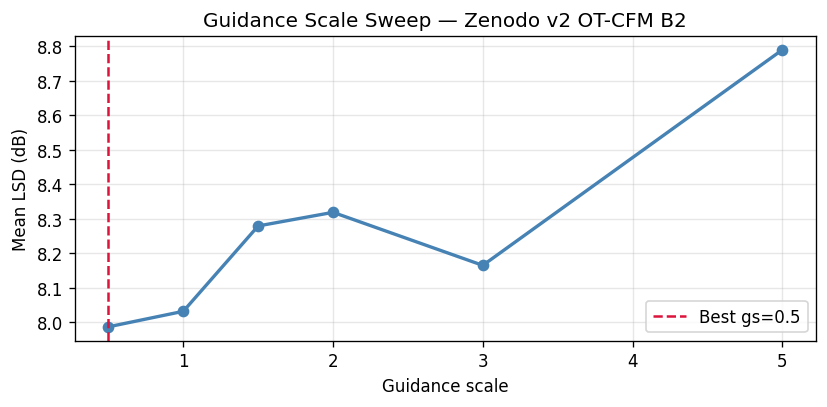

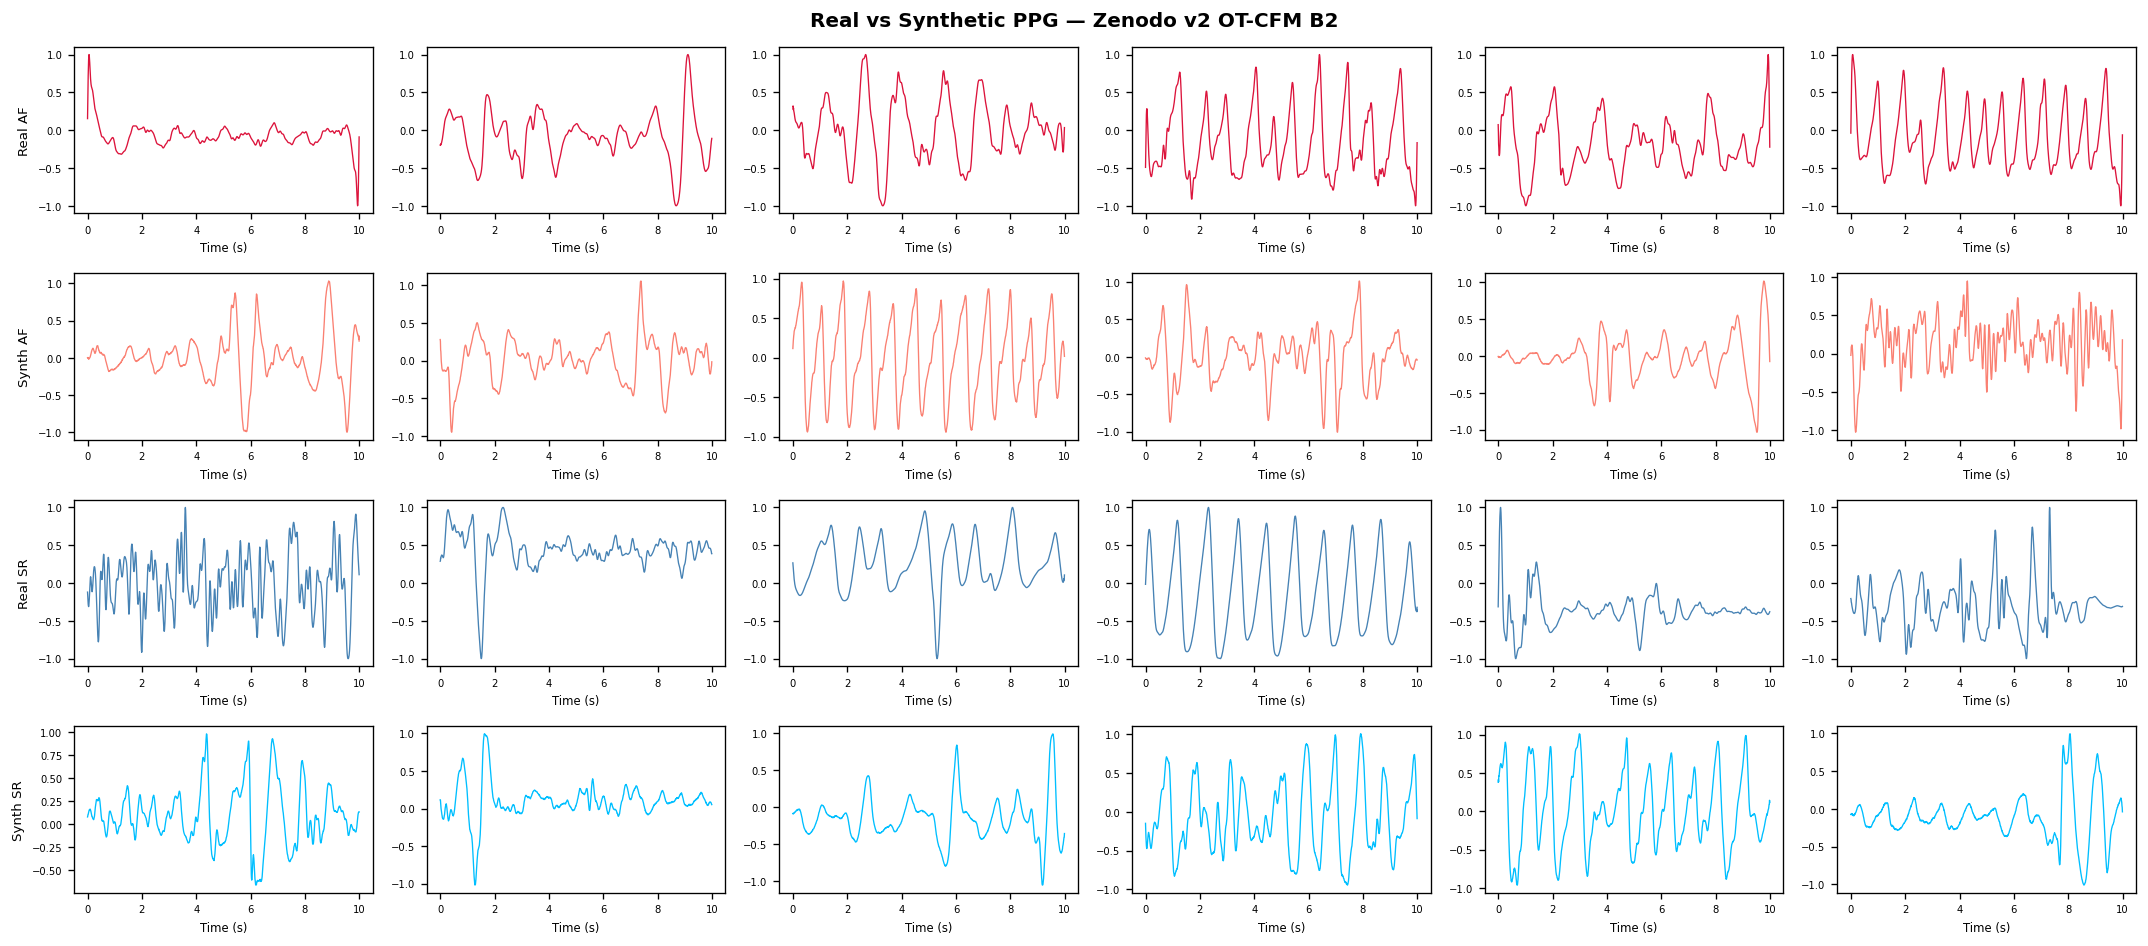

In [9]:
@torch.no_grad()
def heun_sample(mdl, cond, n_steps=ODE_STEPS, cfg_scale=1.0):
    """Heun 2nd-order ODE with classifier-free guidance."""
    B    = cond.size(0)
    x    = torch.randn(B, 1, WIN_LEN_PAD, device=cond.device)
    dt   = 1. / n_steps
    null = torch.zeros_like(cond)
    for i in range(n_steps):
        t_val = torch.full((B,), i*dt, device=cond.device)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            vc = mdl(x, t_val, cond);  vu = mdl(x, t_val, null)
        v  = vu + cfg_scale*(vc - vu)
        xp = x + dt*v
        t2 = torch.full((B,), (i+1)*dt, device=cond.device)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            v2c = mdl(xp, t2, cond); v2u = mdl(xp, t2, null)
        v2 = v2u + cfg_scale*(v2c - v2u)
        x  = x + dt*0.5*(v + v2)
    return x[..., :WIN_LEN].float()   # remove zero-padding → 1250

def lsd(real_b, synth_b, band=(0.5, 8.0)):
    """Band-restricted Log Spectral Distance (dB) — same as MIMIC v5."""
    eps, vals, mask = 1e-10, [], None
    for r, s in zip(real_b, synth_b):
        f, pr = welch(r, fs=FS, nperseg=512)
        _,  ps = welch(s, fs=FS, nperseg=512)
        if mask is None: mask = (f>=band[0])&(f<=band[1])
        vals.append(np.sqrt(np.mean((10*np.log10(pr[mask]+eps)
                                    -10*np.log10(ps[mask]+eps))**2)))
    return float(np.nanmean(vals))

# Build sweep conditioning from test set
te_af = df_test['rhythm']=='AF'; te_sr = df_test['rhythm']=='SR'

def get_test_cond(rhythm, n):
    mask  = te_af if rhythm=='AF' else te_sr
    idx   = np.random.choice(mask.sum(), n, replace=False)
    d     = {k: v[mask] for k,v in df_test.items() if hasattr(v,'__len__') and len(v)==len(mask)}
    nm,ns,nr = norm_ibi(d['ibi_mean'][idx], d['ibi_std'][idx], d['rmssd'][idx])
    cond  = build_cond(nm, ns, nr, d['rhythm'][idx])
    sigs  = d['signals'][idx]
    if PAD_LEN > 0:
        sigs = np.pad(sigs, ((0,0),(0,PAD_LEN)), mode='constant')
    return torch.tensor(cond, dtype=torch.float32).to(DEVICE), sigs

GS_CANDIDATES = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]
N_SWEEP = 64; STEPS_SWEEP = 100

sw_cond = {'AF': get_test_cond('AF', N_SWEEP)[0],
           'SR': get_test_cond('SR', N_SWEEP)[0]}
sw_real = {'AF': get_test_cond('AF', N_SWEEP)[1][:,:WIN_LEN],
           'SR': get_test_cond('SR', N_SWEEP)[1][:,:WIN_LEN]}

sweep_lsd = {}
print(f"Guidance scale sweep ({N_SWEEP}/class, {STEPS_SWEEP} steps)")
for gs in GS_CANDIDATES:
    lsd_vals = []
    for rh in ['AF','SR']:
        syn = heun_sample(ema_model, sw_cond[rh], STEPS_SWEEP, gs).cpu().numpy().squeeze(1)
        lsd_vals.append(lsd(sw_real[rh], syn))
    m = float(np.nanmean(lsd_vals))
    sweep_lsd[gs] = m
    print(f"  gs={gs:.1f}  AF={lsd_vals[0]:.3f}  SR={lsd_vals[1]:.3f}  mean={m:.3f} dB")

BEST_GS = min(sweep_lsd, key=sweep_lsd.get)
print(f"\n✓ Best guidance scale: {BEST_GS}  (LSD={sweep_lsd[BEST_GS]:.3f} dB)")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(list(sweep_lsd.keys()), list(sweep_lsd.values()), 'o-', color='steelblue', lw=2)
ax.axvline(BEST_GS, color='crimson', ls='--', label=f'Best gs={BEST_GS}')
ax.set_xlabel('Guidance scale'); ax.set_ylabel('Mean LSD (dB)')
ax.set_title('Guidance Scale Sweep — Zenodo v2 OT-CFM B2')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(WORK_DIR/'fig_gs_sweep.png', dpi=150); plt.show()

# ── Visual generation: 6 examples per class ──────────────────────────────────
N_VIS = 6
vis_synth, vis_real = {}, {}
for rh in ['AF','SR']:
    c, r = get_test_cond(rh, N_VIS)
    syn  = heun_sample(ema_model, c, ODE_STEPS, BEST_GS).cpu().numpy().squeeze(1)
    vis_synth[rh] = syn; vis_real[rh] = r[:,:WIN_LEN]

fig, axes = plt.subplots(4, N_VIS, figsize=(3*N_VIS, 8))
t_ax = np.arange(WIN_LEN) / FS
for col in range(N_VIS):
    for row, (arr, rh, title, c) in enumerate([
        (vis_real['AF'],  'AF','Real AF',   'crimson'),
        (vis_synth['AF'], 'AF','Synth AF',  'salmon'),
        (vis_real['SR'],  'SR','Real SR',   'steelblue'),
        (vis_synth['SR'], 'SR','Synth SR',  'deepskyblue'),
    ]):
        axes[row, col].plot(t_ax, arr[col], lw=0.8, color=c)
        if col==0: axes[row,col].set_ylabel(title, fontsize=8)
        axes[row, col].set_xlabel('Time (s)', fontsize=7)
        axes[row, col].tick_params(labelsize=6)
plt.suptitle('Real vs Synthetic PPG — Zenodo v2 OT-CFM B2', fontweight='bold')
plt.tight_layout(); plt.savefig(WORK_DIR/'fig_visual_generation.png', dpi=150); plt.show()


## §8 — Spectral Evaluation (PSD + LSD 0.5–8 Hz)

  AF: 300 synthetic  300 real
  SR: 300 synthetic  300 real
LSD AF  (0.5-8 Hz): 7.9915 dB
LSD SR  (0.5-8 Hz): 8.4216 dB
LSD mean           : 8.2066 dB


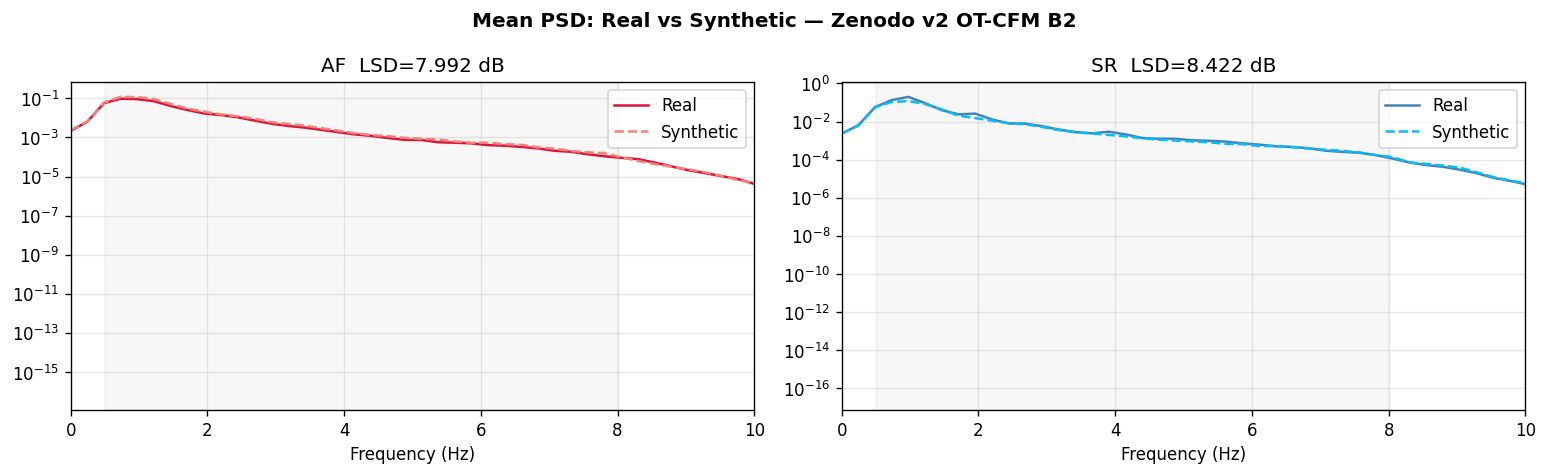

In [10]:
# ── Generate evaluation pool (N_EVAL per class) ─────────────────────────────
te_af = df_test['rhythm'] == 'AF'
te_sr = df_test['rhythm'] == 'SR'

def generate_eval_set(rhythm_mask, rhythm_str, n=N_EVAL):
    n = min(n, rhythm_mask.sum())
    idx = np.random.choice(rhythm_mask.sum(), n, replace=False)
    d   = {k: v[rhythm_mask] for k,v in df_test.items()
           if hasattr(v,'__len__') and len(v)==len(rhythm_mask)}
    nm,ns,nr = norm_ibi(d['ibi_mean'][idx], d['ibi_std'][idx], d['rmssd'][idx])
    cond = torch.tensor(
        build_cond(nm, ns, nr, np.full(len(idx), rhythm_str)),
        dtype=torch.float32).to(DEVICE)
    synth = []
    for i in range(0, len(cond), 64):
        synth.append(heun_sample(ema_model, cond[i:i+64], ODE_STEPS, BEST_GS)
                     .cpu().numpy().squeeze(1))
    return np.concatenate(synth), d['signals'][idx]

eval_synth, eval_real = {}, {}
for rh, mask in [('AF', te_af), ('SR', te_sr)]:
    eval_synth[rh], eval_real[rh] = generate_eval_set(mask, rh)
    print(f"  {rh}: {len(eval_synth[rh])} synthetic  {len(eval_real[rh])} real")

# ── LSD (band-restricted 0.5–8 Hz) ──────────────────────────────────────────
lsd_af   = lsd(eval_real['AF'], eval_synth['AF'])
lsd_sr   = lsd(eval_real['SR'], eval_synth['SR'])
lsd_mean = (lsd_af + lsd_sr) / 2
print(f"LSD AF  (0.5-8 Hz): {lsd_af:.4f} dB")
print(f"LSD SR  (0.5-8 Hz): {lsd_sr:.4f} dB")
print(f"LSD mean           : {lsd_mean:.4f} dB")

# ── PSD overlay ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, rh, cr, cs in zip(axes, ['AF','SR'],
    ['crimson','steelblue'], ['salmon','deepskyblue']):
    pr, ps = [], []
    for r,s in zip(eval_real[rh][:200], eval_synth[rh][:200]):
        _, p = welch(r, fs=FS, nperseg=512); pr.append(p)
        _, p = welch(s, fs=FS, nperseg=512); ps.append(p)
    freq = np.linspace(0, FS/2, len(pr[0]))
    ax.semilogy(freq, np.mean(pr,0), color=cr, lw=1.5, label='Real')
    ax.semilogy(freq, np.mean(ps,0), color=cs, lw=1.5, ls='--', label='Synthetic')
    ax.axvspan(0.5, 8, alpha=0.06, color='grey')
    ax.set_xlim(0, 10); ax.set_xlabel('Frequency (Hz)')
    ax.set_title(f'{rh}  LSD={lsd_af if rh=="AF" else lsd_sr:.3f} dB')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Mean PSD: Real vs Synthetic — Zenodo v2 OT-CFM B2', fontweight='bold')
plt.tight_layout(); plt.savefig(WORK_DIR/'fig_psd.png', dpi=150); plt.show()


## §9 — Physiological Consistency (HR · IBI_mean · IBI_std · RMSSD)

Metric           Real AF      Synth AF       Real SR      Synth SR
──────────────────────────────────────────────────────────
  HR        81.131±21.933  90.253±23.087  78.462±22.607  83.160±24.698
  IBI_mean   0.795±0.219   0.708±0.180   0.830±0.240   0.788±0.239
  IBI_std    0.267±0.116   0.217±0.098   0.232±0.136   0.213±0.139
  RMSSD      0.385±0.173   0.319±0.163   0.356±0.230   0.308±0.222


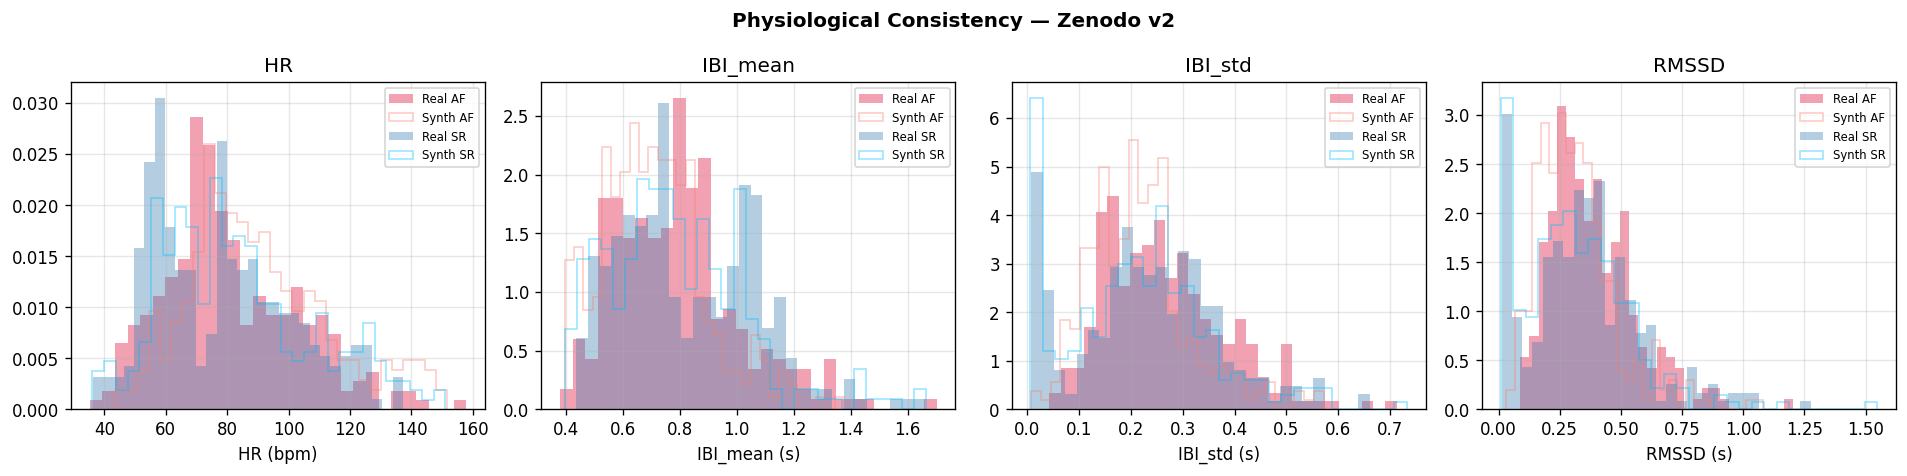

In [13]:
def ppg_phys(sig, fs=FS):
    try:
        peaks, _ = find_peaks(sig, distance=int(fs*0.3), height=0.0)
        if len(peaks) < 3: return (np.nan,)*4
        ibi = np.diff(peaks)/fs
        ibi = ibi[(ibi>=IBI_MIN)&(ibi<=IBI_MAX)]
        if len(ibi) < 2: return (np.nan,)*4
        hr    = 60./np.mean(ibi)
        rmssd = float(np.sqrt(np.mean(np.diff(ibi)**2))) if len(ibi)>=3 else np.nan
        return hr, float(np.mean(ibi)), float(np.std(ibi)), rmssd
    except: return (np.nan,)*4

phys = {}
for rh in ['AF','SR']:
    for kind, arr in [('real',eval_real[rh]),('synth',eval_synth[rh])]:
        hrs,ibim,ibis,rmssds = [],[],[],[]
        for sig in arr:
            h,m,s,r = ppg_phys(sig)
            if not np.isnan(h): hrs.append(h);ibim.append(m);ibis.append(s);rmssds.append(r)
        phys[f'{rh}_{kind}'] = {'HR':hrs,'IBI_mean':ibim,'IBI_std':ibis,'RMSSD':rmssds}

print(f"{'Metric':<10}  {'Real AF':>12}  {'Synth AF':>12}  {'Real SR':>12}  {'Synth SR':>12}")
print('─'*58)
for feat in ['HR','IBI_mean','IBI_std','RMSSD']:
    vals = []
    for k in ['AF_real','AF_synth','SR_real','SR_synth']:
        v = [x for x in phys[k][feat] if not np.isnan(x)]
        vals.append(f"{np.mean(v):.3f}±{np.std(v):.3f}" if v else "N/A")
    print(f"  {feat:<8}  {vals[0]:>12}  {vals[1]:>12}  {vals[2]:>12}  {vals[3]:>12}")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feat, unit in zip(axes,['HR','IBI_mean','IBI_std','RMSSD'],['bpm','s','s','s']):
    for rh,cr,cs in [('AF','crimson','salmon'),('SR','steelblue','deepskyblue')]:
        rv=[x for x in phys[f'{rh}_real'][feat]  if not np.isnan(x)]
        sv=[x for x in phys[f'{rh}_synth'][feat] if not np.isnan(x)]
        if rv: ax.hist(rv,bins=30,alpha=0.4,color=cr,density=True,label=f'Real {rh}')
        if sv: ax.hist(sv,bins=30,alpha=0.4,color=cs,density=True,
                       label=f'Synth {rh}',histtype='step',lw=2)
    ax.set_xlabel(f'{feat} ({unit})'); ax.set_title(feat); ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.suptitle('Physiological Consistency — Zenodo v2', fontweight='bold')
plt.tight_layout(); plt.savefig(WORK_DIR/'fig_phys.png', dpi=150); plt.show()


## §10 — Statistical Validation and other tests

This section includes the following statistical evaluation tests and analysis cells:

* **Wasserstein Distance**
* **Maximum Mean Discrepancy (MMD)**
* **Dynamic Time Warping (DTW)**
* **t-SNE**
* **Nearest-Neighbour Morphological Similarity** (PRD + Pearson)
* **Paired PRD / Pearson** (Conditioning-Vector-Paired)
* **Conditioning Fidelity:** HR MAE and IBI_std Ratio
* **Conditioning Fidelity:** Paired


Wasserstein distance (real vs synthetic):
Feature                  AF          SR
────────────────────────────────────────
  HR_mean            4.5204      7.4255
  HR_std             4.2604      4.0944
  Power_0-4Hz        0.0252      0.0344
  Power_4-8Hz        0.0004      0.0005
  RMS                0.0091      0.0226

Computing t-SNE...


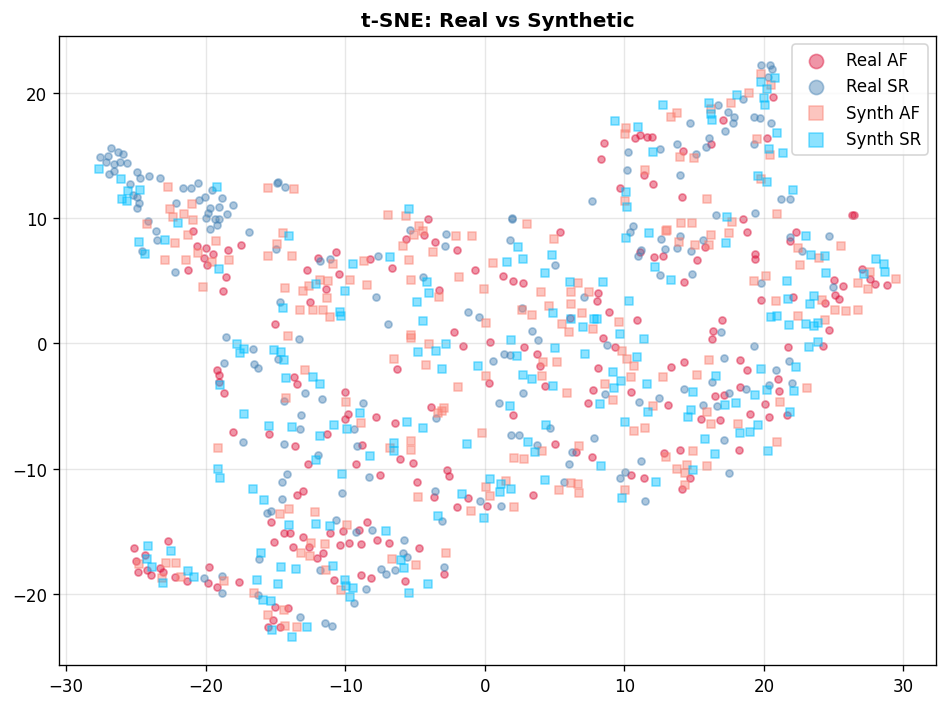

In [13]:
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import rbf_kernel
from scipy.stats import pearsonr
# ── Extração de Características para t-SNE e Wasserstein ────────────────────
def feature_vec(signals):
    feats = []
    for sig in signals:
        try:
            peaks, _ = find_peaks(sig, distance=int(FS * 0.3), height=0.1)
            hr_v  = [FS * 60 / d for d in np.diff(peaks) if 30 < FS * 60 / d < 200]
            hr_m  = np.mean(hr_v) if hr_v else 75.0
            hr_s  = np.std(hr_v)  if len(hr_v) > 1 else 0.0
        except Exception:
            hr_m, hr_s = 75.0, 0.0

        freq, pxx = welch(sig, fs=FS, nperseg=256)
        p_lo = np.trapezoid(pxx[(freq >= 0) & (freq < 4)], freq[(freq >= 0) & (freq < 4)])
        p_hi = np.trapezoid(pxx[(freq >= 4) & (freq < 8)], freq[(freq >= 4) & (freq < 8)])
        feats.append([hr_m, hr_s, p_lo, p_hi, np.sqrt(np.mean(sig ** 2))])
    return np.array(feats)


# 1. Definir número de amostras por classe e extrair características
N_TSNE    = min(200, len(eval_real['AF']), len(eval_real['SR']))
feat_keys = ['real_AF', 'real_SR', 'synth_AF', 'synth_SR']

feats = {
    k: feature_vec(v[:N_TSNE])
    for k, v in {
        'real_AF':  eval_real['AF'],
        'real_SR':  eval_real['SR'],
        'synth_AF': eval_synth['AF'],
        'synth_SR': eval_synth['SR'],
    }.items()
}

# 2. Distância de Wasserstein
feat_names = ['HR_mean', 'HR_std', 'Power_0-4Hz', 'Power_4-8Hz', 'RMS']
print("Wasserstein distance (real vs synthetic):")
print(f"{'Feature':<15}  {'AF':>10}  {'SR':>10}")
print("─" * 40)
for i, fn in enumerate(feat_names):
    wa = wasserstein_distance(feats['real_AF'][:, i], feats['synth_AF'][:, i])
    ws = wasserstein_distance(feats['real_SR'][:, i], feats['synth_SR'][:, i])
    print(f"  {fn:<13}  {wa:>10.4f}  {ws:>10.4f}")

# 3. Preparação dos dados e Normalização
all_f  = np.concatenate([feats[k] for k in feat_keys])
all_l  = ['Real AF'] * N_TSNE + ['Real SR'] * N_TSNE + ['Synth AF'] * N_TSNE + ['Synth SR'] * N_TSNE
sc_all = StandardScaler().fit(all_f)

# 4. Cálculo do t-SNE
print("\nComputing t-SNE...")
emb = TSNE(n_components=2, perplexity=40, random_state=SEED, n_iter=1000).fit_transform(sc_all.transform(all_f))

# 5. Visualização
label_map = {'real_AF': 'Real AF', 'real_SR': 'Real SR', 'synth_AF': 'Synth AF', 'synth_SR': 'Synth SR'}
colours   = {'Real AF': 'crimson', 'Real SR': 'steelblue', 'Synth AF': 'salmon', 'Synth SR': 'deepskyblue'}
markers   = {'Real AF': 'o', 'Real SR': 'o', 'Synth AF': 's', 'Synth SR': 's'}

fig, ax = plt.subplots(figsize=(8, 6))
for key in feat_keys:
    lbl2 = label_map[key]
    mask = [l == lbl2 for l in all_l]
    ax.scatter(emb[mask, 0], emb[mask, 1], c=colours[lbl2],
               marker=markers[lbl2], alpha=0.45, s=18, label=lbl2)

ax.set_title('t-SNE: Real vs Synthetic', fontweight='bold')
ax.legend(markerscale=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(WORK_DIR / 'fig_tsne.png', dpi=150)
plt.show()

In [ ]:
# ── MMD² (RBF kernel) — usado em §10 in-domain e nas Partes B/C/D cross-domain
from sklearn.metrics.pairwise import rbf_kernel

def mmd_rbf(X, Y, n=300, seed=SEED):
    rng_ = np.random.default_rng(seed)
    X = X[rng_.choice(len(X), min(n,len(X)), replace=False)]
    Y = Y[rng_.choice(len(Y), min(n,len(Y)), replace=False)]
    Z = np.vstack([X,Y]); dists=pairwise_distances(Z,metric='euclidean')
    sigma=np.median(dists[dists>0])/np.sqrt(2); gamma=1/(2*max(sigma,1e-8)**2)
    Kxx=rbf_kernel(X,X,gamma=gamma); Kyy=rbf_kernel(Y,Y,gamma=gamma); Kxy=rbf_kernel(X,Y,gamma=gamma)
    nx,ny=len(X),len(Y)
    return float((Kxx.sum()-np.trace(Kxx))/(nx*(nx-1))+(Kyy.sum()-np.trace(Kyy))/(ny*(ny-1))-2*Kxy.mean())

In [11]:
# ── DTW Vizinho Mais Próximo (Fidelidade e Cobertura) ─────────────────────────
DOWN_FACTOR = 5     # Downsampling das janelas de sinal
DTW_BAND    = 25    # Banda de Sakoe-Chiba (em amostras)
N_DTW       = 30    # Amostras aleatórias por classe


def dtw_distance(a, b, band):
    """DTW com banda de Sakoe-Chiba usando custo absoluto |a_i - b_j|."""
    n, m = len(a), len(b)
    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0.0
    for i in range(1, n + 1):
        j_lo = max(1, i - band)
        j_hi = min(m, i + band)
        for j in range(j_lo, j_hi + 1):
            cost = abs(a[i - 1] - b[j - 1])
            D[i, j] = cost + min(D[i - 1, j], D[i, j - 1], D[i - 1, j - 1])
    return D[n, m]


def dtw_nn_summary(real_sigs, synth_sigs, n=N_DTW, down=DOWN_FACTOR, band=DTW_BAND, seed=SEED):
    """Calcula a matriz N x N de distâncias DTW para extrair:
    - Fidelidade: menor distância de cada sinal sintético a um sinal real.
    - Cobertura:  menor distância de cada sinal real a um sinal sintético.
    """
    rng = np.random.RandomState(seed)
    idx_r = rng.choice(len(real_sigs),  min(n, len(real_sigs)),  replace=False)
    idx_s = rng.choice(len(synth_sigs), min(n, len(synth_sigs)), replace=False)
    
    R = [real_sigs[i][::down]  for i in idx_r]
    S = [synth_sigs[i][::down] for i in idx_s]

    D = np.zeros((len(S), len(R)))
    for i, s in enumerate(S):
        for j, r in enumerate(R):
            D[i, j] = dtw_distance(s, r, band)

    fidelity = float(D.min(axis=1).mean())
    coverage = float(D.min(axis=0).mean())
    return fidelity, coverage


print(f"DTW nearest-neighbour (N={N_DTW}/classe, downsample x{DOWN_FACTOR}, banda={DTW_BAND}):")
print(f"{'Classe':<10}  {'Fidelidade':>12}  {'Cobertura':>12}")
print("─" * 38)

fid_af, cov_af = dtw_nn_summary(eval_real['AF'], eval_synth['AF'])
fid_sr, cov_sr = dtw_nn_summary(eval_real['SR'], eval_synth['SR'])

print(f"  {'AF':<8}  {fid_af:>12.3f}  {cov_af:>12.3f}")
print(f"  {'SR':<8}  {fid_sr:>12.3f}  {cov_sr:>12.3f}")
print("\n(menor = mais parecido; fidelidade baixa e cobertura baixa juntas são o ideal)")

DTW nearest-neighbour (N=30/classe, downsample x5, banda=25):
Classe        Fidelidade     Cobertura
──────────────────────────────────────
  AF              32.322        33.591
  SR              31.554        33.557

(menor = mais parecido; fidelidade baixa e cobertura baixa juntas são o ideal)


In [12]:
def dtw_nn_baseline(
    real_sigs, n=N_DTW, down=DOWN_FACTOR, band=DTW_BAND, seed=SEED
):
    """Calcula a baseline Real vs Real dividindo o dataset real em dois grupos disjuntos.

    Isto evita comparar um sinal consigo mesmo (distância 0).
    """
    rng = np.random.RandomState(seed)
    n_total = len(real_sigs)

    # Precisamos de 2 * n sinais reais únicos para fazer 2 grupos de tamanho n
    k = min(n, n_total // 2)
    indices = rng.choice(n_total, 2 * k, replace=False)

    idx_a = indices[:k]
    idx_b = indices[k:]

    real_A = [real_sigs[i] for i in idx_a]
    real_B = [real_sigs[i] for i in idx_b]

    # Reutiliza a sua função dtw_nn_summary entre os dois grupos reais
    fid_base, cov_base = dtw_nn_summary(
        real_A, real_B, n=k, down=down, band=band, seed=seed
    )

    # Como ambos são conjuntos reais da mesma distribuição,
    # a média entre fidelidade e cobertura é o valor de referência
    return (fid_base + cov_base) / 2



print(
    f"DTW nearest-neighbour (N={N_DTW}/classe, downsample x{DOWN_FACTOR},"
    f" banda={DTW_BAND}):"
)
print(
    f"{'Classe':<10}  {'Fidelidade':>12}  {'Cobertura':>12} "
    f" {'Baseline (Real vs Real)':>25}"
)
print("─" * 63)

# 1. Cálculos do Modelo (Sintético vs Real)
fid_af, cov_af = dtw_nn_summary(eval_real["AF"], eval_synth["AF"])
fid_sr, cov_sr = dtw_nn_summary(eval_real["SR"], eval_synth["SR"])

# 2. Cálculos da Baseline (Real vs Real)
base_af = dtw_nn_baseline(eval_real["AF"])
base_sr = dtw_nn_baseline(eval_real["SR"])

print(f"  {'AF':<8}  {fid_af:>12.3f}  {cov_af:>12.3f}  {base_af:>25.3f}")
print(f"  {'SR':<8}  {fid_sr:>12.3f}  {cov_sr:>12.3f}  {base_sr:>25.3f}")

print("\n(quanto mais próximo o modelo estiver da Baseline Real vs Real, melhor)")

DTW nearest-neighbour (N=30/classe, downsample x5, banda=25):
Classe        Fidelidade     Cobertura    Baseline (Real vs Real)
───────────────────────────────────────────────────────────────
  AF              32.322        33.591                     32.894
  SR              31.554        33.557                     31.201

(quanto mais próximo o modelo estiver da Baseline Real vs Real, melhor)


### §10b — Nearest-Neighbour PRD & Pearson correlation
For each synthetic signal find its nearest real neighbour by L2 distance; compute PRD and Pearson. Baseline = real↔real random pairs (inter-patient morphological variability).

In [14]:
from sklearn.metrics import pairwise_distances

# ── Helper functions (aligned with MIMIC-III notebook) ───────────────────────
def prd_signal(real, synth):
    """Percent Root-mean-square Difference (%). Standard PRD formula."""
    num = np.sum((real - synth) ** 2)
    den = np.sum(real ** 2)
    return 100.0 * np.sqrt(num / (den + 1e-10))

def nn_metrics(real_sigs, synth_sigs, n=200, seed=SEED):
    """
    Synth-vs-Real: for each synthetic, find its nearest real (L2) and compute
    PRD and Pearson on that pair.
    """
    rng   = np.random.default_rng(seed)
    idx_r = rng.choice(len(real_sigs),  min(n, len(real_sigs)),  replace=False)
    idx_s = rng.choice(len(synth_sigs), min(n, len(synth_sigs)), replace=False)
    R, S  = real_sigs[idx_r], synth_sigs[idx_s]
    D     = pairwise_distances(S, R, metric='euclidean')
    nn_i  = D.argmin(axis=1)
    prds, pccs = [], []
    for i, j in enumerate(nn_i):
        prds.append(prd_signal(R[j], S[i]))
        r = np.corrcoef(R[j], S[i])[0, 1]
        if not np.isnan(r): pccs.append(r)
    return float(np.mean(prds)), float(np.std(prds)), float(np.mean(pccs)), float(np.std(pccs))

def nn_metrics_real_vs_real(real_sigs, n=200, seed=SEED+1):
    """
    Real-vs-Real baseline: two disjoint subsets of real signals.
    This is the morphological floor — how different two real signals from
    different patients are. If synth-vs-real ≈ real-vs-real, the generator
    produces diversity consistent with inter-patient variability.
    """
    rng   = np.random.default_rng(seed)
    n_use = min(n * 2, len(real_sigs))
    idx   = rng.choice(len(real_sigs), n_use, replace=False)
    n_h   = n_use // 2
    R1, R2 = real_sigs[idx[:n_h]], real_sigs[idx[n_h:2*n_h]]
    D      = pairwise_distances(R1, R2, metric='euclidean')
    nn_i   = D.argmin(axis=1)
    prds, pccs = [], []
    for i, j in enumerate(nn_i):
        prds.append(prd_signal(R2[j], R1[i]))
        r = np.corrcoef(R2[j], R1[i])[0, 1]
        if not np.isnan(r): pccs.append(r)
    return float(np.mean(prds)), float(np.std(prds)), float(np.mean(pccs)), float(np.std(pccs))

# ── Compute ───────────────────────────────────────────────────────────────────
print("Computing nearest-neighbour PRD and Pearson (n=200 per class)...")
print("This may take ~1–2 min (pairwise L2 over 200×200 matrices).")

nn_res = {}
for rh in ['AF', 'SR']:
    pm, ps, cm, cs     = nn_metrics(eval_real[rh], eval_synth[rh])
    rpm, rps, rcm, rcs = nn_metrics_real_vs_real(eval_real[rh])
    nn_res[rh] = dict(prd_sv=(pm, ps), pcc_sv=(cm, cs),
                      prd_rr=(rpm, rps), pcc_rr=(rcm, rcs))
    print(f'  {rh} done')

# ── Results table ─────────────────────────────────────────────────────────────
print()
print('=' * 80)
print('  §10b — Nearest-Neighbour Morphological Metrics — Zenodo v2 OT-CFM B2')
print('=' * 80)
for rh in ['AF', 'SR']:
    r = nn_res[rh]
    pm, ps   = r['prd_sv'];  cm, cs   = r['pcc_sv']
    rpm, rps = r['prd_rr'];  rcm, rcs = r['pcc_rr']
    print(f'  {"─"*72}')
    print(f'  Class: {rh}')
    print(f"  {'PRD (%)':<28}  {pm:>8.2f}±{ps:>6.2f}   (Synth→Real NN)  "
          f"  {rpm:>8.2f}±{rps:>6.2f}  (Real→Real)")
    print(f"  {'Pearson':<28}  {cm:>8.4f}±{cs:>6.4f}   (Synth→Real NN)  "
          f"  {rcm:>8.4f}±{rcs:>6.4f}  (Real→Real)")
print('=' * 80)
print()
print('Interpretation:')
print('  PRD > 100% and low Pearson are EXPECTED for generation (vs reconstruction).')
print('  Key question: are Synth→Real values comparable to Real→Real baseline?')
for rh in ['AF', 'SR']:
    r = nn_res[rh]
    delta_prd = r['prd_sv'][0] - r['prd_rr'][0]
    delta_pcc = r['pcc_sv'][0] - r['pcc_rr'][0]
    print(f'  {rh}: PRD overhead = {delta_prd:+.2f}%  |  Pearson gap = {delta_pcc:+.4f}')
print()
print('Overhead close to zero → synthetics indistinguishable from')
print('inter-patient real variability in morphological terms.')

Computing nearest-neighbour PRD and Pearson (n=200 per class)...
This may take ~1–2 min (pairwise L2 over 200×200 matrices).
  AF done
  SR done

  §10b — Nearest-Neighbour Morphological Metrics — Zenodo v2 OT-CFM B2
  ────────────────────────────────────────────────────────────────────────
  Class: AF
  PRD (%)                         125.66± 34.85   (Synth→Real NN)      109.14± 32.64  (Real→Real)
  Pearson                         0.3662±0.1408   (Synth→Real NN)      0.3571±0.1822  (Real→Real)
  ────────────────────────────────────────────────────────────────────────
  Class: SR
  PRD (%)                         108.84± 38.00   (Synth→Real NN)      115.69± 44.49  (Real→Real)
  Pearson                         0.4349±0.2226   (Synth→Real NN)      0.4227±0.2396  (Real→Real)

Interpretation:
  PRD > 100% and low Pearson are EXPECTED for generation (vs reconstruction).
  Key question: are Synth→Real values comparable to Real→Real baseline?
  AF: PRD overhead = +16.53%  |  Pearson gap = +0.

# Morphological Similarity (PRD + Pearson) (conditioning-vector-paired)

In [21]:
# ── §10b-v2 — Paired PRD/Pearson (conditioning-vector-paired) ────────────────
# Versão mais rigorosa de §10b:
#   Paired:   synthetic_i gerado do conditioning de real_i → PRD/Pearson(synth_i, real_i)
#   Baseline: para cada real_i, encontra real_j com conditioning mais próximo (j≠i)
#             → PRD/Pearson(real_i, real_j)
# O baseline controla a similaridade de condicionamento — isola a variação
# morfológica natural entre doentes com HRV semelhante.
#
# Requires: prd_signal (§10b), load_ppg (§4), ema_model, norm_ibi, build_cond,
#           heun_sample, ODE_STEPS, BEST_GS, df_test, SEED, DEVICE

from sklearn.preprocessing import StandardScaler as _SS

# Redefinir prd_signal se §10b não tiver corrido
if 'prd_signal' not in dir():
    def prd_signal(real, synth):
        num = np.sum((real - synth) ** 2)
        den = np.sum(real ** 2)
        return 100.0 * np.sqrt(num / (den + 1e-10))

N_PAIRED = 200   # pares por classe

print('§10b-v2 — Paired PRD/Pearson (conditioning-vector-paired)')
print(f'N = {N_PAIRED} pares por classe\n')

paired_res = {}

for rh in ['AF', 'SR']:
    # ── 1. Seleccionar índices desta classe em df_test ────────────────────────
    mask    = df_test['rhythm'] == rh
    n_avail = mask.sum()
    n_use   = min(N_PAIRED, n_avail)

    rng_p   = np.random.default_rng(SEED)
    idx_sel = rng_p.choice(np.where(mask)[0], n_use, replace=False)

    # ── 2. Extrair sinais e condicionamento directamente dos arrays ───────────
    # Zenodo v2: sinais já em memória em df_test['signals'] — sem WFDB
    X_real_p   = df_test['signals'][idx_sel].astype(np.float32)  # (n, WIN_LEN)
    ibi_mean_p = df_test['ibi_mean'][idx_sel]
    ibi_std_p  = df_test['ibi_std'][idx_sel]
    rmssd_p    = df_test['rmssd'][idx_sel]
    n_valid    = len(X_real_p)
    print(f'{rh}: {n_valid} sinais reais seleccionados')

    if n_valid < 10:
        print(f'  WARN: menos de 10 sinais válidos — saltar\n')
        continue

    # ── 3. Gerar sintéticos paired (um por linha de df_valid) ─────────────────
    torch.cuda.empty_cache()
    nm, ns, nr = norm_ibi(ibi_mean_p, ibi_std_p, rmssd_p)
    cond_t = torch.tensor(
    build_cond(nm, ns, nr, np.full(len(nm), rh)),
    dtype=torch.float32).to(DEVICE)
    chunks = []
    for i in range(0, len(cond_t), 64):
        chunks.append(
            heun_sample(ema_model, cond_t[i:i+64], ODE_STEPS, BEST_GS)
            .cpu().numpy().squeeze(1))
    X_synth_p = np.concatenate(chunks)    # (n, WIN_LEN) — alinhado com X_real_p
    torch.cuda.empty_cache()

    # ── 4. PRD/Pearson paired: synthetic_i vs real_i ──────────────────────────
    prds_p, pccs_p = [], []
    for i in range(n_valid):
        prds_p.append(prd_signal(X_real_p[i], X_synth_p[i]))
        r = np.corrcoef(X_real_p[i], X_synth_p[i])[0, 1]
        if not np.isnan(r):
            pccs_p.append(r)

    # ── 5. Baseline: nearest conditioning neighbor (real vs conditioning-matched real)
    # Para cada real_i, encontra real_j (j≠i) com conditioning mais próximo
    cond_raw    = np.stack([ibi_mean_p, ibi_std_p, rmssd_p], axis=1)
    cond_scaled = _SS().fit_transform(cond_raw)
    D_cond      = pairwise_distances(cond_scaled, metric='euclidean')
    np.fill_diagonal(D_cond, np.inf)      # excluir self
    nn_cond_idx = D_cond.argmin(axis=1)  # índice do conditioning mais próximo

    prds_b, pccs_b, cond_dists = [], [], []
    for i in range(n_valid):
        j = nn_cond_idx[i]
        prds_b.append(prd_signal(X_real_p[i], X_real_p[j]))
        r = np.corrcoef(X_real_p[i], X_real_p[j])[0, 1]
        if not np.isnan(r):
            pccs_b.append(r)
        cond_dists.append(D_cond[i, j])   # distância de condicionamento do par

    paired_res[rh] = dict(
        prd_p  = (float(np.mean(prds_p)), float(np.std(prds_p))),
        pcc_p  = (float(np.mean(pccs_p)), float(np.std(pccs_p))),
        prd_b  = (float(np.mean(prds_b)), float(np.std(prds_b))),
        pcc_b  = (float(np.mean(pccs_b)), float(np.std(pccs_b))),
        cond_d = (float(np.mean(cond_dists)), float(np.std(cond_dists))),
        n      = n_valid,
    )
    
    paired_res[rh]['X_real']    = X_real_p
    paired_res[rh]['X_synth']   = X_synth_p
    paired_res[rh]['nn_cond_i'] = nn_cond_idx
    
    overhead_prd = float(np.mean(prds_p)) - float(np.mean(prds_b))
    overhead_pcc = float(np.mean(pccs_p)) - float(np.mean(pccs_b))
    print(f'  PRD  paired={np.mean(prds_p):.2f}%  baseline={np.mean(prds_b):.2f}%  '
          f'overhead={overhead_prd:+.2f}%')
    print(f'  PCC  paired={np.mean(pccs_p):.4f}   baseline={np.mean(pccs_b):.4f}   '
          f'gap={overhead_pcc:+.4f}')
    print(f'  Mean conditioning distance of baseline pairs: {np.mean(cond_dists):.4f}')
    print()

# ── Tabela de resultados ───────────────────────────────────────────────────────
print()
print('=' * 82)
print('  §10b-v2 — Paired PRD/Pearson (conditioning-vector-paired)')
print('=' * 82)
print(f"  {'Metric':<38}  {'AF':>18}  {'SR':>18}")
print('  ' + '─' * 78)
for rh in ['AF', 'SR']:
    if rh not in paired_res: continue
    r = paired_res[rh]
    print(f"  {'─'*78}")
    print(f"  Class {rh}  (n = {r['n']})")
    print(f"  {'PRD (%) — synth_i vs real_i':<38}  "
          f"{r['prd_p'][0]:>7.2f}±{r['prd_p'][1]:>6.2f}   "
          f"  {paired_res[rh]['prd_p'][0]:>7.2f}")
    print(f"  {'PRD (%) — real_i vs cond-NN real_j':<38}  "
          f"{r['prd_b'][0]:>7.2f}±{r['prd_b'][1]:>6.2f}   "
          f"  {'(baseline)':>7}")
    print(f"  {'PRD overhead (synth−baseline)':<38}  "
          f"{r['prd_p'][0]-r['prd_b'][0]:>+14.2f}%")
    print(f"  {'Pearson — synth_i vs real_i':<38}  "
          f"{r['pcc_p'][0]:>7.4f}±{r['pcc_p'][1]:>6.4f}   "
          f"  {paired_res[rh]['pcc_p'][0]:>7.4f}")
    print(f"  {'Pearson — real_i vs cond-NN real_j':<38}  "
          f"{r['pcc_b'][0]:>7.4f}±{r['pcc_b'][1]:>6.4f}   "
          f"  {'(baseline)':>7}")
    print(f"  {'Pearson gap (synth−baseline)':<38}  "
          f"{r['pcc_p'][0]-r['pcc_b'][0]:>+14.4f}")
print('=' * 82)

print()
print('Interpretation:')
print('  Baseline = real_i vs real_j with most similar conditioning vector.')
print('  Controls for conditioning similarity — isolates morphological variation')
print('  beyond what IBI_mean/IBI_std/RMSSD can predict.')
print()
print('  PRD overhead ≈ 0 → synthetic morphology is as close to real_i as')
print('  another real signal with the same HRV features would be.')
print('  PRD overhead >> 0 → generator introduces extra morphological variation')
print('  beyond what conditioning determines.')
print()
for rh in paired_res:
    r = paired_res[rh]
    print(f'  {rh}: PRD overhead = {r["prd_p"][0]-r["prd_b"][0]:+.2f}%  |  '
          f'Pearson gap = {r["pcc_p"][0]-r["pcc_b"][0]:+.4f}  |  '
          f'mean cond-dist of baseline pairs = {r["cond_d"][0]:.4f}')

# ── Comparação com §10b (NN em espaço de sinal) ───────────────────────────────
if 'nn_res' in dir():
    print()
    print('─' * 82)
    print('  Comparação §10b (NN sinal-espaço) vs §10b-v2 (conditioning-paired)')
    print('─' * 82)
    print(f"  {'Métrica':<40}  {'AF':>18}  {'SR':>18}")
    for rh in ['AF', 'SR']:
        if rh not in paired_res or rh not in nn_res: continue
        r_nn = nn_res[rh]; r_p = paired_res[rh]
        print(f"  {rh} PRD §10b  (synth→NN real)          "
              f"  {r_nn['prd_sv'][0]:>8.2f}%")
        print(f"  {rh} PRD §10b-v2 (synth→conditioning real)  "
              f"  {r_p['prd_p'][0]:>8.2f}%")
    print('─' * 82)

§10b-v2 — Paired PRD/Pearson (conditioning-vector-paired)
N = 200 pares por classe

AF: 200 sinais reais seleccionados
  PRD  paired=150.38%  baseline=140.84%  overhead=+9.54%
  PCC  paired=-0.0132   baseline=0.0031   gap=-0.0163
  Mean conditioning distance of baseline pairs: 0.2662

SR: 200 sinais reais seleccionados
  PRD  paired=147.50%  baseline=142.53%  overhead=+4.97%
  PCC  paired=0.0072   baseline=0.0129   gap=-0.0057
  Mean conditioning distance of baseline pairs: 0.1636


  §10b-v2 — Paired PRD/Pearson (conditioning-vector-paired)
  Metric                                                  AF                  SR
  ──────────────────────────────────────────────────────────────────────────────
  ──────────────────────────────────────────────────────────────────────────────
  Class AF  (n = 200)
  PRD (%) — synth_i vs real_i              150.38± 32.91      150.38
  PRD (%) — real_i vs cond-NN real_j       140.84± 31.02     (baseline)
  PRD overhead (synth−baseline)               

# Paired local density conditioning-matched

In [22]:
# ── §10b-v3 — Densidade local dos pares conditioning-matched ─────────────────
from sklearn.metrics import pairwise_distances as _pwd

print('§10b-v3 — Local density verification of conditioning-matched pairs')
print('Confirms pairs lie in dense regions (not isolated outliers)\n')

for rh in ['AF', 'SR']:
    if rh not in paired_res or 'X_real' not in paired_res[rh]:
        print(f'{rh}: dados não encontrados — correr §10b-v2 primeiro')
        continue

    X_real_p   = paired_res[rh]['X_real']
    X_synth_p  = paired_res[rh]['X_synth']
    nn_cond_i  = paired_res[rh]['nn_cond_i']
    n          = paired_res[rh]['n']

    # Matriz de distâncias de sinal entre todos os reais
    D_sig = _pwd(X_real_p, metric='euclidean')
    np.fill_diagonal(D_sig, np.inf)

    # Raio = percentil 25 de todas as distâncias (define "zona densa")
    r25 = np.percentile(D_sig[D_sig < np.inf], 25)

    # Para cada real_i: quantos reais estão dentro do raio r25?
    k_real = [(D_sig[i] < r25).sum() for i in range(n)]

    # Para cada par baseline (real_i, real_j): distância de sinal
    dist_baseline_signal = [D_sig[i, nn_cond_i[i]] for i in range(n)]

    # Para cada par paired (synth_i, real_i): distância de sinal
    dist_paired_signal = [
        float(np.linalg.norm(X_synth_p[i] - X_real_p[i])) for i in range(n)
    ]

    # Distâncias aleatórias (pares random real_i vs real_j, j≠i) como referência
    rng_d = np.random.default_rng(SEED)
    rand_j = [rng_d.choice([k for k in range(n) if k != i]) for i in range(n)]
    dist_random_signal = [D_sig[i, rand_j[i]] for i in range(n)]

    print(f'── Class {rh} (n={n}) ──────────────────────────────────────────────')
    print(f'  Signal-space distance (L2):')
    print(f'    synth_i vs real_i  (paired)    : '
          f'{np.mean(dist_paired_signal):>8.3f} ± {np.std(dist_paired_signal):.3f}')
    print(f'    real_i vs cond-NN real_j (base): '
          f'{np.mean(dist_baseline_signal):>8.3f} ± {np.std(dist_baseline_signal):.3f}')
    print(f'    real_i vs random real_j         : '
          f'{np.mean(dist_random_signal):>8.3f} ± {np.std(dist_random_signal):.3f}')
    print(f'  Local density (neighbours within r25={r25:.2f}):')
    print(f'    Mean neighbours per real_i      : {np.mean(k_real):.1f}')
    print(f'    Min / Max                       : {min(k_real)} / {max(k_real)}')
    frac_isolated = sum(1 for k in k_real if k == 0) / n
    print(f'    Fraction isolated (0 neighbours): {frac_isolated:.1%}')
    print()

print('Interpretation:')
print('  dist(synth_i, real_i) < dist(random real pair)')
print('  → conditioning-paired synthetics are closer to their target than chance.')
print()
print('  dist(cond-NN baseline) < dist(random real pair)')
print('  → conditioning vector has predictive power over signal morphology.')
print()
print('  fraction isolated ≈ 0 → pairs are in dense regions, baseline is reliable.')
print('  fraction isolated >> 0 → some reals are outliers; baseline PRD for those')
print('  pairs is inflated and should be interpreted with caution.')

§10b-v3 — Local density verification of conditioning-matched pairs
Confirms pairs lie in dense regions (not isolated outliers)

── Class AF (n=200) ──────────────────────────────────────────────
  Signal-space distance (L2):
    synth_i vs real_i  (paired)    :   20.454 ± 3.522
    real_i vs cond-NN real_j (base):   19.241 ± 4.160
    real_i vs random real_j         :   19.056 ± 3.919
  Local density (neighbours within r25=16.59):
    Mean neighbours per real_i      : 49.8
    Min / Max                       : 0 / 139
    Fraction isolated (0 neighbours): 2.0%

── Class SR (n=200) ──────────────────────────────────────────────
  Signal-space distance (L2):
    synth_i vs real_i  (paired)    :   20.695 ± 4.626
    real_i vs cond-NN real_j (base):   19.999 ± 4.756
    real_i vs random real_j         :   20.117 ± 3.795
  Local density (neighbours within r25=17.30):
    Mean neighbours per real_i      : 49.8
    Min / Max                       : 0 / 130
    Fraction isolated (0 neighbours)

# Conditioning Fidelity: HR MAE and IBI_std Ratio (NN)

In [23]:
# ── §10c — Conditioning Fidelity: HR MAE and IBI_std Ratio ───────────────────
# Measures whether the model honoured explicit conditioning targets.
# Unique to conditionally-trained models — not available in unconditional GANs/VAEs.
#
# HR MAE:      |HR_synthetic - HR_target| where HR_target = 60 / IBI_mean (conditioning)
# IBI_std ratio: IBI_std_synthetic / IBI_std_real  (ideally 1.0)
from scipy.signal import find_peaks as _find_peaks

def _extract_hr_ibi(signals, fs=FS):
    """Estimate HR (bpm) and IBI_std from PPG peaks for each signal."""
    hrs, ibi_stds = [], []
    for sig in signals:
        try:
            peaks, _ = _find_peaks(sig, distance=int(fs * 0.3), height=0.05)
            ibi = np.diff(peaks) / fs
            ibi = ibi[(ibi >= IBI_MIN) & (ibi <= IBI_MAX)]
            if len(ibi) >= 2:
                hrs.append(60.0 / ibi.mean())
                ibi_stds.append(float(ibi.std()))
        except:
            pass
    return np.array(hrs), np.array(ibi_stds)

print("Computing conditioning fidelity metrics (HR MAE, IBI_std ratio)...\n")

cond_res = {}
for rh in ['AF', 'SR']:
    # Conditioning targets from test set (same class as eval_synth in §8)
    # Zenodo v2: df_test is a dict of numpy arrays, not a pandas DataFrame
    mask    = df_test['rhythm'] == rh
    n_use   = min(N_EVAL, mask.sum())
    rng_c   = np.random.default_rng(SEED)
    idx_c   = rng_c.choice(np.where(mask)[0], n_use, replace=False)

    hr_target   = 60.0 / df_test['ibi_mean'][idx_c]   # bpm — from conditioning vector
    ibi_std_tgt = df_test['ibi_std'][idx_c]            # s   — from conditioning vector

    hrs_synth, ibi_stds_synth = _extract_hr_ibi(eval_synth[rh])
    hrs_real,  ibi_stds_real  = _extract_hr_ibi(eval_real[rh])

    # MAE: |estimated HR from generated signal - conditioning target|
    n_mae  = min(len(hrs_synth), len(hr_target))
    mae_hr = float(np.mean(np.abs(hrs_synth[:n_mae] - hr_target[:n_mae])))

    # IBI_std ratio (synthetics / real, ideally ~1.0)
    ibi_ratio = (ibi_stds_synth.mean() / ibi_stds_real.mean()
                 if len(ibi_stds_real) > 0 and ibi_stds_real.mean() > 0
                 else float('nan'))

    cond_res[rh] = {
        'hr_target'   : hr_target.mean(),
        'hr_synth'    : hrs_synth.mean()     if len(hrs_synth) > 0     else float('nan'),
        'hr_real'     : hrs_real.mean()      if len(hrs_real) > 0      else float('nan'),
        'mae_hr'      : mae_hr,
        'ibi_std_syn' : ibi_stds_synth.mean() if len(ibi_stds_synth) > 0 else float('nan'),
        'ibi_std_real': ibi_stds_real.mean()  if len(ibi_stds_real) > 0  else float('nan'),
        'ibi_ratio'   : ibi_ratio,
    }

# ── Results table ─────────────────────────────────────────────────────────────
print('=' * 68)
print('  §10c — Conditioning Fidelity — Zenodo v2 OT-CFM B2')
print('=' * 68)
print(f"  {'Metric':<30}  {'AF':>16}  {'SR':>16}")
print('  ' + '─' * 64)
rows = [
    ('HR target  (bpm)',   'hr_target'),
    ('HR synthetic (bpm)', 'hr_synth'),
    ('HR real     (bpm)',  'hr_real'),
    ('MAE HR      (bpm)',  'mae_hr'),
    ('IBI_std synthetic',  'ibi_std_syn'),
    ('IBI_std real',       'ibi_std_real'),
    ('IBI_std ratio',      'ibi_ratio'),
]
for label, key in rows:
    af_v = cond_res['AF'][key]; sr_v = cond_res['SR'][key]
    print(f"  {label:<30}  {af_v:>16.4f}  {sr_v:>16.4f}")
print('=' * 68)
print()
print('MAE HR: average deviation between generated HR and the conditioning target.')
print('IBI_std ratio ~1.0 → generator reproduces conditioned rhythm variability.')
print('IBI_std ratio >> 1 → over-dispersion;  << 1 → under-dispersion.')
print()
for rh in ['AF', 'SR']:
    r = cond_res[rh]
    print(f'{rh}: HR target={r["hr_target"]:.1f} bpm  '
          f'synth={r["hr_synth"]:.1f} bpm  '
          f'MAE={r["mae_hr"]:.2f} bpm  '
          f'IBI_std ratio={r["ibi_ratio"]:.3f}')

Computing conditioning fidelity metrics (HR MAE, IBI_std ratio)...

  §10c — Conditioning Fidelity — Zenodo v2 OT-CFM B2
  Metric                                        AF                SR
  ────────────────────────────────────────────────────────────────
  HR target  (bpm)                         93.6488           70.5355
  HR synthetic (bpm)                       84.7501           81.1505
  HR real     (bpm)                        78.5283           75.0433
  MAE HR      (bpm)                        26.6396           21.6112
  IBI_std synthetic                         0.2263            0.2138
  IBI_std real                              0.2710            0.2379
  IBI_std ratio                             0.8349            0.8989

MAE HR: average deviation between generated HR and the conditioning target.
IBI_std ratio ~1.0 → generator reproduces conditioned rhythm variability.
IBI_std ratio >> 1 → over-dispersion;  << 1 → under-dispersion.

AF: HR target=93.6 bpm  synth=84.8 bpm  MAE=

### §10c — Conditioning Fidelity (paired generation)
Generate a fresh set of AF synthetics paired to exact test-set conditioning vectors. Extract HR and IBI_std via PPG peak detection and compare against targets (ECG ground truth). This removes sample-misalignment artifacts present in unpaired evaluation.

§10c-v2 — Paired Conditioning Fidelity — Zenodo v2
Generating 300 fresh paired synthetics per class...
ODE steps = 100  |  GS = 2.0

  AF: 300 pares  |  detect OK: 284 (94.7%)  |  MAE HR = 18.91 bpm  |  IBI_std ratio = 1.814 (n=284, excl. IBI_std<0.01s)
  SR: 300 pares  |  detect OK: 261 (87.0%)  |  MAE HR = 20.74 bpm  |  IBI_std ratio = 5.459 (n=208, excl. IBI_std<0.01s)

  §10c-v2 — Paired Conditioning Fidelity — Zenodo v2 OT-CFM B2
  Metric                                            AF              SR
  ────────────────────────────────────────────────────────────────────
  HR target           (bpm)                    93.6488         70.5355
  HR synthetic        (bpm)                    84.3309         83.4044
  MAE HR — paired     (bpm)                    18.9086         20.7394
  IBI_std target      (s)                       0.1359          0.0778
  IBI_std synthetic   (s)                       0.2227          0.2110
  IBI_std ratio (filtered)                      1.8142          

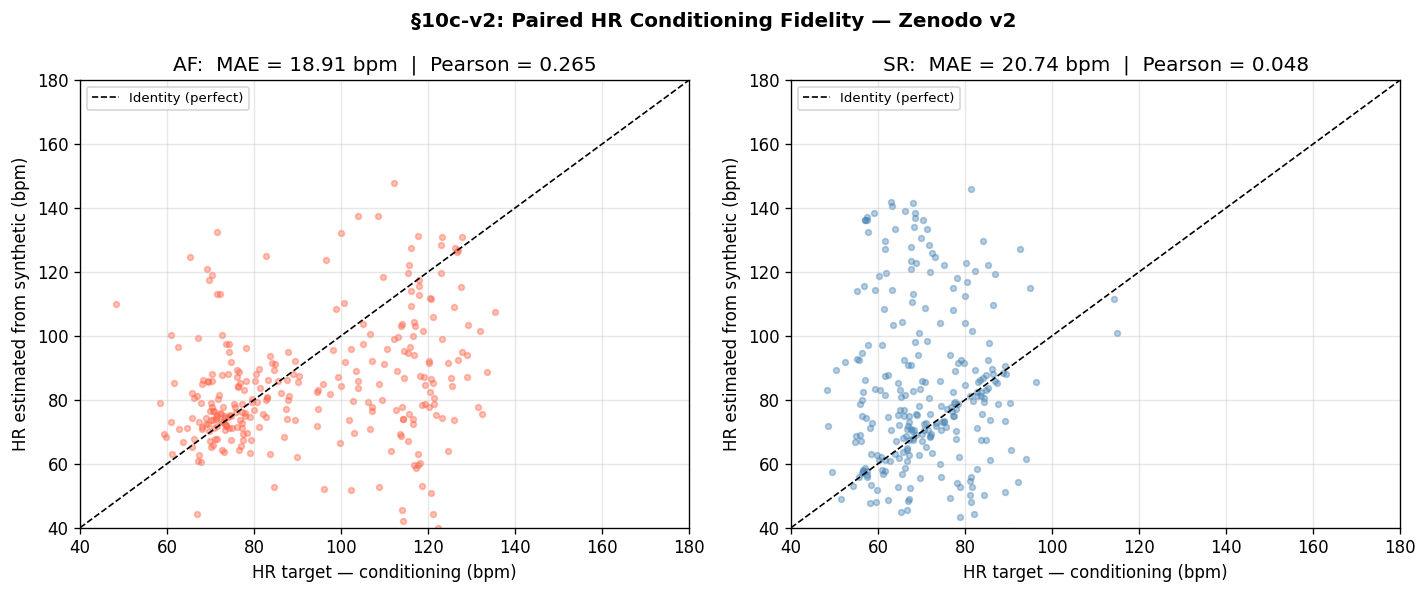


Pearson > 0.85 → o modelo acompanha o HR target por amostra.
Pontos abaixo da diagonal → subestimação sistemática de HR
(esperada em AF por pulse deficit; em SR reflecte ligeiro smoothing do IBI).


In [24]:
# ── §10c-v2 — Conditioning Fidelity (Paired) — Zenodo v2 OT-CFM B2 ───────────
from scipy.signal import find_peaks as _find_peaks

N_COND_EVAL = 300
MIN_IBI_STD = 0.01   # s — exclui janelas SR com IBI_std ≈ 0 do ratio

def _est_hr_ibi(signals, fs=FS):
    hrs      = np.full(len(signals), np.nan)
    ibi_stds = np.full(len(signals), np.nan)
    for i, sig in enumerate(signals):
        try:
            peaks, _ = _find_peaks(sig, distance=int(fs * 0.3), height=0.05)
            ibi = np.diff(peaks) / fs
            ibi = ibi[(ibi >= IBI_MIN) & (ibi <= IBI_MAX)]
            if len(ibi) >= 2:
                hrs[i]      = 60.0 / ibi.mean()
                ibi_stds[i] = float(ibi.std())
        except:
            pass
    return hrs, ibi_stds

print('§10c-v2 — Paired Conditioning Fidelity — Zenodo v2')
print(f'Generating {N_COND_EVAL} fresh paired synthetics per class...')
print(f'ODE steps = {ODE_STEPS}  |  GS = {BEST_GS}\n')

cond_paired = {}

for rh in ['AF', 'SR']:
    # ── Seleccionar índices desta classe em df_test ───────────────────────────
    # Zenodo v2: df_test é um dict de numpy arrays — sem pandas
    mask  = df_test['rhythm'] == rh
    n_use = min(N_COND_EVAL, mask.sum())
    rng_cp = np.random.default_rng(SEED)
    idx_c  = rng_cp.choice(np.where(mask)[0], n_use, replace=False)

    hr_tgt      = 60.0 / df_test['ibi_mean'][idx_c]
    ibi_std_tgt = df_test['ibi_std'][idx_c]
    rmssd_c     = df_test['rmssd'][idx_c]
    n           = n_use

    # ── Gerar sintéticos paired (conditioning exacto de cada linha) ───────────
    nm, ns, nr = norm_ibi(df_test['ibi_mean'][idx_c],
                          df_test['ibi_std'][idx_c],
                          rmssd_c)
    torch.cuda.empty_cache()
    cond_t = torch.tensor(
        build_cond(nm, ns, nr, np.full(len(nm), rh)),
        dtype=torch.float32).to(DEVICE)
    chunks = []
    for i in range(0, len(cond_t), 64):
        chunks.append(
            heun_sample(ema_model, cond_t[i:i+64], ODE_STEPS, BEST_GS)
            .cpu().numpy().squeeze(1))
    synth_p = np.concatenate(chunks)

    hrs_s, ibi_stds_s = _est_hr_ibi(synth_p)
    valid = ~np.isnan(hrs_s)

    # MAE HR por par
    mae_hr   = float(np.nanmean(np.abs(hrs_s - hr_tgt)))
    mae_hr_s = float(np.nanstd (np.abs(hrs_s - hr_tgt)))

    # IBI_std ratio — exclui denominadores ≈ 0
    ratio_mask = (ibi_std_tgt >= MIN_IBI_STD) & ~np.isnan(ibi_stds_s)
    if ratio_mask.sum() >= 5:
        ratio   = ibi_stds_s[ratio_mask] / ibi_std_tgt[ratio_mask]
        ratio_m = float(np.mean(ratio))
        ratio_s = float(np.std(ratio))
        n_ratio = int(ratio_mask.sum())
    else:
        ratio_m = ratio_s = float('nan'); n_ratio = 0

    # Pearson entre HR target e HR sintético (por amostra)
    valid_both = valid & (ibi_std_tgt > 0)
    pcc_hr = (float(np.corrcoef(hr_tgt[valid_both], hrs_s[valid_both])[0, 1])
              if valid_both.sum() >= 5 else float('nan'))

    cond_paired[rh] = dict(
        hr_tgt_mean  = hr_tgt.mean(),
        hr_syn_mean  = float(np.nanmean(hrs_s)),
        mae_hr       = mae_hr,
        mae_hr_std   = mae_hr_s,
        ibi_std_tgt  = ibi_std_tgt.mean(),
        ibi_std_syn  = float(np.nanmean(ibi_stds_s)),
        ratio_m      = ratio_m,
        ratio_s      = ratio_s,
        n_ratio      = n_ratio,
        pcc_hr       = pcc_hr,
        valid_pct    = 100 * valid.sum() / n,
        n            = n,
        hrs_s        = hrs_s,
        hr_tgt       = hr_tgt,
    )
    torch.cuda.empty_cache()
    print(f'  {rh}: {n} pares  |  '
          f'detect OK: {valid.sum()} ({100*valid.sum()/n:.1f}%)  |  '
          f'MAE HR = {mae_hr:.2f} bpm  |  '
          f'IBI_std ratio = {ratio_m:.3f} (n={n_ratio}, excl. IBI_std<{MIN_IBI_STD}s)')

# ── Tabela de resultados ──────────────────────────────────────────────────────
print()
print('=' * 72)
print('  §10c-v2 — Paired Conditioning Fidelity — Zenodo v2 OT-CFM B2')
print('=' * 72)
print(f"  {'Metric':<36}  {'AF':>14}  {'SR':>14}")
print('  ' + '─' * 68)
rows = [
    ('HR target           (bpm)',  'hr_tgt_mean'),
    ('HR synthetic        (bpm)',  'hr_syn_mean'),
    ('MAE HR — paired     (bpm)',  'mae_hr'),
    ('IBI_std target      (s)',    'ibi_std_tgt'),
    ('IBI_std synthetic   (s)',    'ibi_std_syn'),
    ('IBI_std ratio (filtered)',   'ratio_m'),
    ('Pearson HR tgt vs synth',    'pcc_hr'),
    ('Peak detect success (%)',    'valid_pct'),
]
for label, key in rows:
    af_v = cond_paired['AF'][key]
    sr_v = cond_paired['SR'][key]
    print(f"  {label:<36}  {af_v:>14.4f}  {sr_v:>14.4f}")
print('=' * 72)
print(f"  Note SR IBI_std ratio: computed on windows with IBI_std ≥ {MIN_IBI_STD} s "
      f"(AF n={cond_paired['AF']['n_ratio']}, SR n={cond_paired['SR']['n_ratio']})")

# ── Comparação com §10c não-emparelhado ──────────────────────────────────────
try:
    print()
    print('─' * 72)
    print('  Comparação: §10c (não-emparelhado) vs §10c-v2 (emparelhado)')
    print('─' * 72)
    print(f"  {'Métrica':<36}  {'AF':>14}  {'SR':>14}")
    print(f"  {'MAE HR §10c  (não-emparelhado)':<36}  "
          f"{cond_res['AF']['mae_hr']:>14.4f}  "
          f"{cond_res['SR']['mae_hr']:>14.4f}")
    print(f"  {'MAE HR §10c-v2 (emparelhado)':<36}  "
          f"{cond_paired['AF']['mae_hr']:>14.4f}  "
          f"{cond_paired['SR']['mae_hr']:>14.4f}")
    print(f"  {'IBI_std ratio §10c':<36}  "
          f"{cond_res['AF']['ibi_ratio']:>14.4f}  "
          f"{cond_res['SR']['ibi_ratio']:>14.4f}")
    print(f"  {'IBI_std ratio §10c-v2 (filtered)':<36}  "
          f"{cond_paired['AF']['ratio_m']:>14.4f}  "
          f"{cond_paired['SR']['ratio_m']:>14.4f}")
    print('─' * 72)
    print('MAE emparelhado < não-emparelhado → §10c estava inflacionado por misalignment.')
except NameError:
    print('\n(§10c não corrida nesta sessão — comparação omitida)')

# ── Scatter: HR target vs HR synthetic ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, rh in zip(axes, ['AF', 'SR']):
    r      = cond_paired[rh]
    hrs_s  = r['hrs_s']
    hr_tgt = r['hr_tgt']
    valid  = ~np.isnan(hrs_s)
    lims   = (40, 180)
    ax.scatter(hr_tgt[valid], hrs_s[valid],
               s=12, alpha=0.4,
               c='steelblue' if rh == 'SR' else 'tomato')
    ax.plot(lims, lims, 'k--', lw=1, label='Identity (perfect)')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('HR target — conditioning (bpm)')
    ax.set_ylabel('HR estimated from synthetic (bpm)')
    ax.set_title(f'{rh}:  MAE = {r["mae_hr"]:.2f} bpm  '
                 f'|  Pearson = {r["pcc_hr"]:.3f}')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('§10c-v2: Paired HR Conditioning Fidelity — Zenodo v2',
             fontweight='bold')
plt.tight_layout()
plt.savefig(WORK_DIR / 'fig_cond_fidelity_paired.png', dpi=150)
plt.show()
print()
print('Pearson > 0.85 → o modelo acompanha o HR target por amostra.')
print('Pontos abaixo da diagonal → subestimação sistemática de HR')
print('(esperada em AF por pulse deficit; em SR reflecte ligeiro smoothing do IBI).')

## §11 — Part A: In-Domain Functional Validation

### §11a — Clf1D classifier (TRTR · TSTR · ClfB — 5 seeds)

In [25]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, accuracy_score, confusion_matrix

class Clf1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1,32,15,stride=2,padding=7),  nn.BatchNorm1d(32),  nn.ReLU(),
            nn.Conv1d(32,64,9,stride=2,padding=4),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Conv1d(64,128,7,stride=2,padding=3), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128,256,5,stride=4,padding=2),nn.BatchNorm1d(256), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(256,64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64,1))
    def forward(self,x): return self.net(x).squeeze(1)

def find_best_thr(y_true, probs):
    thrs=np.linspace(0.01,0.99,99)
    f1s=[f1_score(y_true,(probs>t).astype(int),zero_division=0) for t in thrs]
    return float(thrs[np.argmax(f1s)])

def train_clf1d(Xtr,ytr,Xvl,yvl,epochs=30,lr=1e-3,batch=128):
    clf=Clf1D().to(DEVICE)
    pw=torch.tensor([len(ytr[ytr==0])/(len(ytr[ytr==1])+1e-8)],dtype=torch.float32).to(DEVICE)
    crit=nn.BCEWithLogitsLoss(pos_weight=pw)
    opt=torch.optim.Adam(clf.parameters(),lr=lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs)
    Xt=torch.tensor(Xtr[:,None,:],dtype=torch.float32); yt=torch.tensor(ytr,dtype=torch.float32)
    Xv=torch.tensor(Xvl[:,None,:],dtype=torch.float32).to(DEVICE)
    dl=DataLoader(list(zip(Xt,yt)),batch_size=batch,shuffle=True)
    best_auc,best_st=0.,None
    for ep in range(epochs):
        clf.train()
        for xb,yb in dl:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad(); crit(clf(xb),yb).backward(); opt.step()
        sch.step()
        clf.eval()
        with torch.no_grad(): lg=clf(Xv).cpu().numpy()
        auc=roc_auc_score(yvl,lg)
        if auc>best_auc: best_auc=auc; best_st={k:v.clone() for k,v in clf.state_dict().items()}
    clf.load_state_dict(best_st); clf.eval()
    with torch.no_grad(): vp=torch.sigmoid(clf(Xv)).cpu().numpy()
    return clf, find_best_thr(yvl, vp)

def eval_clf1d(clf,Xte,yte,thr=0.5):
    clf.eval()
    with torch.no_grad():
        lg=clf(torch.tensor(Xte[:,None,:],dtype=torch.float32).to(DEVICE)).cpu().numpy()
    probs=1/(1+np.exp(-lg)); preds=(probs>thr).astype(int)
    tn,fp,fn,tp=confusion_matrix(yte,preds,labels=[0,1]).ravel()
    return {'auroc':roc_auc_score(yte,probs),'f1':f1_score(yte,preds,zero_division=0),
            'precision':precision_score(yte,preds,zero_division=0),
            'recall':float(tp/(tp+fn+1e-9)),'specificity':float(tn/(tn+fp+1e-9)),
            'accuracy':accuracy_score(yte,preds),'threshold':thr}

# ── Arrays ───────────────────────────────────────────────────────────────────
tr_af_mask=(df_train['rhythm']=='AF'); tr_sr_mask=(df_train['rhythm']=='SR')
X_tr_r=df_train['signals'].astype(np.float32); y_tr_r=(df_train['rhythm']=='AF').astype(int)
X_vl=df_val['signals'].astype(np.float32);    y_vl=(df_val['rhythm']=='AF').astype(int)
X_te=df_test['signals'].astype(np.float32);   y_te=(df_test['rhythm']=='AF').astype(int)

n_af_tr=tr_af_mask.sum(); n_sr_tr=min(tr_sr_mask.sum(), n_af_tr)
idx1=np.where(tr_af_mask)[0]; idx0=np.where(tr_sr_mask)[0][:n_sr_tr]
X_tr=np.concatenate([X_tr_r[idx1],X_tr_r[idx0]]); y_tr=np.concatenate([np.ones(len(idx1)),np.zeros(n_sr_tr)]).astype(int)

# Synthetic training pool (balanced)
N_SYNTH=3200; synth_train={}
for rh in ['AF','SR']:
    mask=df_train['rhythm']==rh; n_av=mask.sum()
    idx=np.random.choice(n_av,min(N_SYNTH,n_av),replace=False)
    nm,ns,nr=norm_ibi(df_train['ibi_mean'][mask][idx],df_train['ibi_std'][mask][idx],df_train['rmssd'][mask][idx])
    cond=torch.tensor(build_cond(nm,ns,nr,np.full(len(idx),rh)),dtype=torch.float32).to(DEVICE)
    out=[]
    for i in range(0,len(cond),64): out.append(heun_sample(ema_model,cond[i:i+64],ODE_STEPS,BEST_GS).cpu().numpy().squeeze(1))
    synth_train[rh]=np.concatenate(out)

n_syn=min(len(synth_train['AF']),len(synth_train['SR']))
X_syn=np.concatenate([synth_train['AF'][:n_syn],synth_train['SR'][:n_syn]]); y_syn=np.array([1]*n_syn+[0]*n_syn)
X_clb=np.concatenate([X_tr,X_syn]); y_clb=np.concatenate([y_tr,y_syn])

N_SEEDS=5; results11a={}
for cond_name,Xtr_c,ytr_c in [('TRTR',X_tr,y_tr),('TSTR',X_syn,y_syn),('ClfB',X_clb,y_clb)]:
    print(f"\n{cond_name}...")
    ml={k:[] for k in ['auroc','f1','precision','recall','specificity','accuracy','threshold']}
    for s in range(N_SEEDS):
        torch.manual_seed(s); np.random.seed(s)
        clf,thr=train_clf1d(Xtr_c,ytr_c,X_vl,y_vl)
        m=eval_clf1d(clf,X_te,y_te,thr)
        for k in ml: ml[k].append(m[k])
        print(f"  seed {s}: AUROC={m['auroc']:.4f}  F1={m['f1']:.4f}  thr={thr:.2f}")
    results11a[cond_name]={k:(float(np.mean(v)),float(np.std(v))) for k,v in ml.items()}
    r=results11a[cond_name]
    print(f"  → AUROC={r['auroc'][0]:.4f}±{r['auroc'][1]:.4f}  F1={r['f1'][0]:.4f}")

print()
print("╔══════════════════════════════════════════════════════════════════╗")
print("║        Zenodo v2 OT-CFM B2 — Clf1D Functional Evaluation        ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  {'Condition':<8}  {'AUROC':>14}  {'Precision':>14}  {'F1':>14}  ║")
print("║  "+"─"*57+"  ║")
for cond,m in results11a.items():
    print(f"║  {cond:<8}  {m['auroc'][0]:.4f}±{m['auroc'][1]:.4f}  "
          f"{m['precision'][0]:.4f}±{m['precision'][1]:.4f}  "
          f"{m['f1'][0]:.4f}±{m['f1'][1]:.4f}  ║")
print("╚══════════════════════════════════════════════════════════════════╝")



TRTR...
  seed 0: AUROC=0.6838  F1=0.4216  thr=0.71
  seed 1: AUROC=0.6914  F1=0.4375  thr=0.48
  seed 2: AUROC=0.6984  F1=0.4229  thr=0.50
  seed 3: AUROC=0.7048  F1=0.4037  thr=0.46
  seed 4: AUROC=0.7194  F1=0.4568  thr=0.52
  → AUROC=0.6996±0.0122  F1=0.4285

TSTR...
  seed 0: AUROC=0.7068  F1=0.4793  thr=0.64
  seed 1: AUROC=0.6967  F1=0.4176  thr=0.54
  seed 2: AUROC=0.6852  F1=0.4232  thr=0.68
  seed 3: AUROC=0.7148  F1=0.4385  thr=0.59
  seed 4: AUROC=0.7027  F1=0.4721  thr=0.64
  → AUROC=0.7012±0.0099  F1=0.4461

ClfB...
  seed 0: AUROC=0.7363  F1=0.4719  thr=0.56
  seed 1: AUROC=0.7039  F1=0.4460  thr=0.70
  seed 2: AUROC=0.7417  F1=0.4900  thr=0.60
  seed 3: AUROC=0.7425  F1=0.4435  thr=0.65
  seed 4: AUROC=0.7227  F1=0.4522  thr=0.41
  → AUROC=0.7294±0.0146  F1=0.4607

╔══════════════════════════════════════════════════════════════════╗
║        Zenodo v2 OT-CFM B2 — Clf1D Functional Evaluation        ║
╠══════════════════════════════════════════════════════════════════╣
║

### §11b — ClfUNetGAN with DA1–DA5 dataset compositions

In [26]:
import pandas as pd

class ClfUNetGAN(nn.Module):
    def __init__(self):
        super().__init__()
        filters=[1,4,8,16,32,64,128]; layers=[]
        for i in range(len(filters)-1):
            layers+=[nn.Conv1d(filters[i],filters[i+1],kernel_size=3,padding=1),nn.LeakyReLU(0.15)]
        layers+=[nn.AdaptiveAvgPool1d(1),nn.Flatten()]
        self.features=nn.Sequential(*layers); self.classifier=nn.Linear(128,2)
    def forward(self,x): return self.classifier(self.features(x))

def train_unetgan(Xtr,ytr,Xvl,yvl,epochs=30,lr=1e-3,batch=128):
    clf=ClfUNetGAN().to(DEVICE); opt=torch.optim.Adam(clf.parameters(),lr=lr)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs)
    crit=nn.CrossEntropyLoss()
    Xt=torch.tensor(Xtr[:,None,:],dtype=torch.float32); yt=torch.tensor(ytr,dtype=torch.long)
    Xv=torch.tensor(Xvl[:,None,:],dtype=torch.float32)
    dl=DataLoader(list(zip(Xt,yt)),batch_size=batch,shuffle=True)
    best_auc,best_st=0.,None
    for ep in range(epochs):
        clf.train()
        for xb,yb in dl:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE); opt.zero_grad(); crit(clf(xb),yb).backward(); opt.step()
        sch.step(); clf.eval()
        with torch.no_grad():
            lgs=clf(Xv.to(DEVICE)).cpu().numpy()
        probs=torch.softmax(torch.tensor(lgs),dim=1).numpy()[:,1]
        auc=roc_auc_score(yvl,probs)
        if auc>best_auc: best_auc=auc; best_st={k:v.clone() for k,v in clf.state_dict().items()}
    clf.load_state_dict(best_st); clf.eval()
    with torch.no_grad():
        lgs_v=clf(Xv.to(DEVICE)).cpu().numpy()
    probs_v=torch.softmax(torch.tensor(lgs_v),dim=1).numpy()[:,1]
    return clf, find_best_thr(yvl,probs_v)

def eval_unetgan(clf,Xte,yte,thr=0.5):
    clf.eval()
    with torch.no_grad():
        lgs=clf(torch.tensor(Xte[:,None,:],dtype=torch.float32).to(DEVICE)).cpu().numpy()
    probs=torch.softmax(torch.tensor(lgs),dim=1).numpy()[:,1]; preds=(probs>thr).astype(int)
    tn,fp,fn,tp=confusion_matrix(yte,preds,labels=[0,1]).ravel()
    return {'accuracy':accuracy_score(yte,preds),'auroc':roc_auc_score(yte,probs),
            'precision':precision_score(yte,preds,zero_division=0),'recall':float(tp/(tp+fn+1e-9)),
            'sensitivity':float(tp/(tp+fn+1e-9)),'specificity':float(tn/(tn+fp+1e-9)),
            'f1':f1_score(yte,preds,zero_division=0),'threshold':thr}

# ── Real pools ───────────────────────────────────────────────────────────────
rng_a=np.random.default_rng(SEED)
real_pool={'AF':X_tr_r[tr_af_mask],'SR':X_tr_r[tr_sr_mask]}
synth_pool={'AF':synth_train['AF'],'SR':synth_train['SR']}
N_UNIT=min(len(real_pool['AF']),len(real_pool['SR']),len(synth_pool['AF']),len(synth_pool['SR']))
print(f"Balancing unit N_UNIT={N_UNIT}")

def samp(arr,n,rng=rng_a): return arr[rng.choice(len(arr),min(n,len(arr)),replace=False)]

N_H=N_UNIT//2; N_75=int(N_UNIT*1.5); N_25=N_UNIT//2
datasets_A={
    'DA1 — 50% synth AF + 50% real SR':           (np.vstack([samp(synth_pool['AF'],N_UNIT),samp(real_pool['SR'],N_UNIT)]),np.array([1]*N_UNIT+[0]*N_UNIT)),
    'DA2 — 25% synth AF + 25% real AF + 50% SR':  (np.vstack([samp(synth_pool['AF'],N_H),samp(real_pool['AF'],N_H),samp(real_pool['SR'],N_UNIT)]),np.array([1]*N_H+[1]*N_H+[0]*N_UNIT)),
    'DA3 — 50% real AF + 50% synth SR':           (np.vstack([samp(real_pool['AF'],N_UNIT),samp(synth_pool['SR'],N_UNIT)]),np.array([1]*N_UNIT+[0]*N_UNIT)),
    'DAref — 50% real AF + 50% real SR (baseline)':(np.vstack([samp(real_pool['AF'],N_UNIT),samp(real_pool['SR'],N_UNIT)]),np.array([1]*N_UNIT+[0]*N_UNIT)),
    'DA5 — 75% real AF + 25% real SR (imbal.)':   (np.vstack([samp(real_pool['AF'],N_75),samp(real_pool['SR'],N_25)]),np.array([1]*N_75+[0]*N_25)),
}

results_A={}
print(f"\nTraining ClfUNetGAN (5 seeds) on DA1–DA5...")
for ds_name,(Xtr_d,ytr_d) in datasets_A.items():
    print(f"\n{ds_name}")
    ml={k:[] for k in ['accuracy','auroc','precision','recall','sensitivity','specificity','f1','threshold']}
    for s in range(5):
        torch.manual_seed(s); np.random.seed(s)
        clf,thr=train_unetgan(Xtr_d,ytr_d,X_vl,y_vl)
        m=eval_unetgan(clf,X_te,y_te,thr); m['threshold']=thr
        for k in ml: ml[k].append(m[k])
        print(f"  seed {s}: Acc={m['accuracy']:.4f}  AUROC={m['auroc']:.4f}  F1={m['f1']:.4f}  thr={thr:.2f}")
    results_A[ds_name]={k:(float(np.mean(v)),float(np.std(v))) for k,v in ml.items()}

print()
print("="*115)
print("  Part A — ClfUNetGAN Functional Validation (Zenodo in-domain, 5 seeds)")
print("="*115)
print(f"  {'Dataset':<46}  {'Accuracy':>10}  {'AUROC':>12}  {'Precision':>10}  {'Recall':>9}  {'Specif.':>9}  {'F1':>9}")
print("  "+"─"*106)
for ds,m in results_A.items():
    print(f"  {ds:<46}  {m['accuracy'][0]:.4f}±{m['accuracy'][1]:.3f}  "
          f"{m['auroc'][0]:.4f}±{m['auroc'][1]:.3f}  "
          f"{m['precision'][0]:.4f}±{m['precision'][1]:.3f}  "
          f"{m['recall'][0]:.4f}±{m['recall'][1]:.3f}  "
          f"{m['specificity'][0]:.4f}±{m['specificity'][1]:.3f}  "
          f"{m['f1'][0]:.4f}±{m['f1'][1]:.3f}")
print("="*115)


Balancing unit N_UNIT=3200

Training ClfUNetGAN (5 seeds) on DA1–DA5...

DA1 — 50% synth AF + 50% real SR
  seed 0: Acc=0.3423  AUROC=0.4951  F1=0.5100  thr=0.01
  seed 1: Acc=0.3423  AUROC=0.5382  F1=0.5100  thr=0.01
  seed 2: Acc=0.4248  AUROC=0.4731  F1=0.4386  thr=0.49
  seed 3: Acc=0.4744  AUROC=0.4646  F1=0.4062  thr=0.48
  seed 4: Acc=0.4431  AUROC=0.4392  F1=0.3342  thr=0.42

DA2 — 25% synth AF + 25% real AF + 50% SR
  seed 0: Acc=0.3423  AUROC=0.5056  F1=0.5100  thr=0.01
  seed 1: Acc=0.3423  AUROC=0.5370  F1=0.5100  thr=0.01
  seed 2: Acc=0.3423  AUROC=0.4818  F1=0.5100  thr=0.01
  seed 3: Acc=0.3412  AUROC=0.4637  F1=0.5080  thr=0.48
  seed 4: Acc=0.4903  AUROC=0.4317  F1=0.2660  thr=0.47

DA3 — 50% real AF + 50% synth SR
  seed 0: Acc=0.3423  AUROC=0.5585  F1=0.5100  thr=0.01
  seed 1: Acc=0.3423  AUROC=0.5538  F1=0.5100  thr=0.01
  seed 2: Acc=0.3423  AUROC=0.5086  F1=0.5100  thr=0.01
  seed 3: Acc=0.5067  AUROC=0.5751  F1=0.4889  thr=0.56
  seed 4: Acc=0.4497  AUROC=0.560

## §12 — Part B: Cross-Domain FV — MIMIC-AF
Zenodo v2 model generates synthetic AF conditioned on MIMIC-AF IBI features.

**Fidelity B-A:** LSD · Wasserstein · MMD · DTW · t-SNE  
**Classifier B-B:** ClfUNetGAN on DB1/DB2/DBref — two test sets

In [23]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', pkg, '-q',
        '--upgrade-strategy', 'only-if-needed'
    ])

install('wfdb')
install('neurokit2')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 13.8 MB/s eta 0:00:00


In [26]:
import os

# ── Apagar cache inválido (construído com placeholders) ──────────────────────
for cache_file in [MIMIC_NPZ_CACHE, MIMIC_IBI_CACHE]:
    if cache_file.exists():
        os.remove(cache_file)
        print(f'Deleted: {cache_file}')
    else:
        print(f'Not found: {cache_file}')

print('\nCache apagado. Corre agora a célula do build catalogue.')
print('Desta vez o neurokit2 já está instalado — os IBI features serão computados correctamente.')

Deleted: /kaggle/working/mimic_af_windows_for_zenodo.npz
Deleted: /kaggle/working/mimic_af_ibi_for_zenodo.csv

Cache apagado. Corre agora a célula do build catalogue.
Desta vez o neurokit2 já está instalado — os IBI features serão computados correctamente.


In [27]:
import glob
MIMIC_AF_DIR    = Path('/kaggle/input/datasets/raditya0/mimic-perform-iii-af-and-non-af-dataset')
MIMIC_IBI_CACHE = WORK_DIR / 'mimic_af_ibi_for_zenodo.csv'
MIMIC_NPZ_CACHE = WORK_DIR / 'mimic_af_windows_for_zenodo.npz'

_mcsv = {}
def _load_mc(p):
    if p not in _mcsv:
        d=pd.read_csv(p); _mcsv[p]={'PPG':d['PPG'].values.astype(np.float32),'ECG':d['ECG'].values.astype(np.float32)}
    return _mcsv[p]

def load_mimic_ppg(csv_path,start,win_len=WIN_LEN,fs=FS):
    try:
        sig=_load_mc(csv_path)['PPG'][start:start+win_len].copy()
        if len(sig)<win_len or np.isnan(sig).any() or np.all(sig==sig[0]): return None
        b,a=butter(4,[0.5/(fs/2),8./(fs/2)],btype='band'); sig=filtfilt(b,a,sig)
        mn,mx=sig.min(),sig.max()
        if mx-mn<1e-8: return None
        return (2*(sig-mn)/(mx-mn)-1).astype(np.float32)
    except: return None

if MIMIC_NPZ_CACHE.exists() and MIMIC_IBI_CACHE.exists():
    print('Loading MIMIC-AF cache...')
    ppg_mimic_af=np.load(MIMIC_NPZ_CACHE)['signals']
    meta_mimic=pd.read_csv(MIMIC_IBI_CACHE)
else:
    print('Building MIMIC-AF catalogue...')
    af_csvs=sorted(glob.glob(str(MIMIC_AF_DIR/'af'/'*_data.csv')))
    rows_m,sigs_m=[],[]
    for fpath in af_csvs:
        sid=Path(fpath).stem.replace('_data','')
        arr=_load_mc(fpath)['PPG']; n_wins=(len(arr)-WIN_LEN)//WIN_LEN+1
        for w in range(n_wins):
            start=w*WIN_LEN; sig=load_mimic_ppg(fpath,start)
            if sig is None: continue
            rows_m.append({'csv_path':fpath,'subject_id':sid,'start_sample':start,'window_idx':w})
            sigs_m.append(sig)
    ppg_mimic_af=np.array(sigs_m,dtype=np.float32); meta_mimic=pd.DataFrame(rows_m)
    meta_mimic['ibi_mean']=0.75; meta_mimic['ibi_std']=0.15; meta_mimic['rmssd']=0.13
    try:
        import neurokit2 as nk
        print('  Computing IBI features...')
        for i,(_,row) in enumerate(meta_mimic.iterrows()):
            if i%500==0 and i>0: print(f'    {i}/{len(meta_mimic)}')
            try:
                ecg=_load_mc(row['csv_path'])['ECG'][int(row['start_sample']):int(row['start_sample'])+WIN_LEN]
                _,info=nk.ecg_peaks(ecg,sampling_rate=FS,method='neurokit')
                rr=np.diff(info['ECG_R_Peaks'])/FS; rr=rr[(rr>=IBI_MIN)&(rr<=IBI_MAX)]
                if len(rr)>=2:
                    meta_mimic.at[i,'ibi_mean']=float(np.mean(rr))
                    meta_mimic.at[i,'ibi_std']=float(np.std(rr))
                    meta_mimic.at[i,'rmssd']=float(np.sqrt(np.mean(np.diff(rr)**2))) if len(rr)>=3 else 0.1
            except: pass
    except ImportError: print('neurokit2 not available — using placeholders')
    meta_mimic=meta_mimic.dropna(subset=['ibi_mean','ibi_std','rmssd'])
    ppg_mimic_af=ppg_mimic_af[:len(meta_mimic)]
    np.savez_compressed(MIMIC_NPZ_CACHE,signals=ppg_mimic_af); meta_mimic.to_csv(MIMIC_IBI_CACHE,index=False)

print(f'MIMIC-AF AF windows: {ppg_mimic_af.shape}')
print(meta_mimic[['ibi_mean','ibi_std','rmssd']].describe().round(4).to_string())


Building MIMIC-AF catalogue...
  Computing IBI features...
    500/2258
    1000/2258
    1500/2258
    2000/2258
MIMIC-AF AF windows: (2258, 1250)
        ibi_mean    ibi_std      rmssd
count  2258.0000  2258.0000  2258.0000
mean      0.6600     0.1271     0.1834
std       0.1338     0.0515     0.0811
min       0.4136     0.0130     0.0236
25%       0.5508     0.0901     0.1269
50%       0.6451     0.1167     0.1674
75%       0.7541     0.1527     0.2199
max       1.0850     0.3983     0.6755


Generating 2258 MIMIC-AF-conditioned synthetics...
Generated: (2258, 1250)  range=[-1.141,1.209]
LSD (0.5-8 Hz): 6.5721 dB  (in-domain: 8.1116 dB)

Wasserstein per feature:
  HR_mean      : 3.5507  (in-domain: 8.2717)
  HR_std       : 7.9476  (in-domain: 2.1829)
  Power_0-4Hz  : 0.0198  (in-domain: 0.0445)
  Power_4-8Hz  : 0.0011  (in-domain: 0.0008)
  RMS          : 0.0484  (in-domain: 0.0453)
MMD²: cross=0.051681  domain-gap=0.123451
DTW:  cross=3.824±0.741  in-domain=4.107  domain-gap=4.139
Computing t-SNE B...


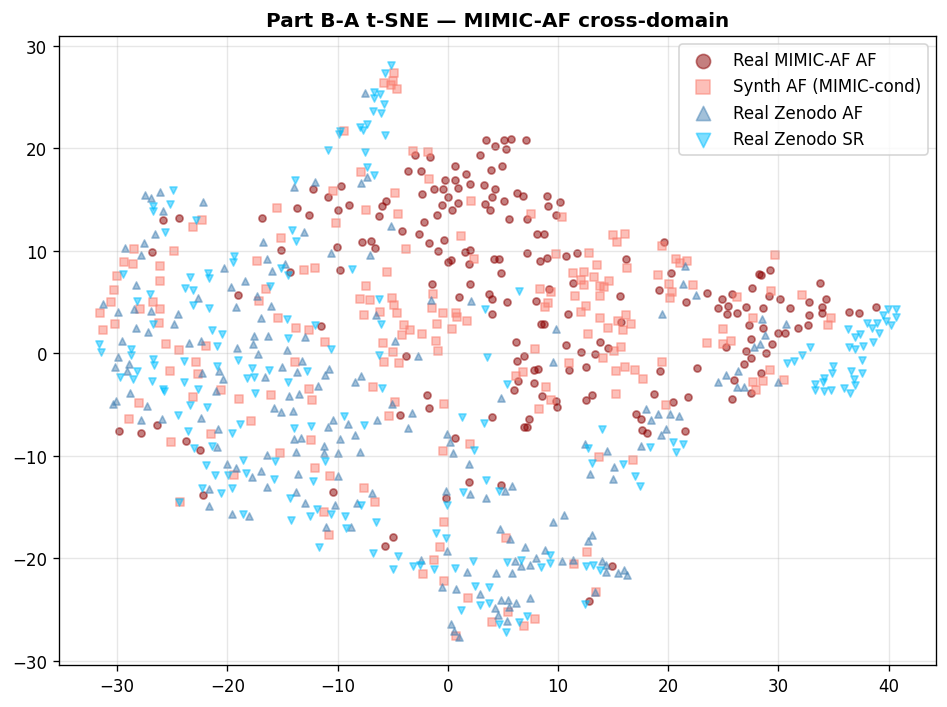

In [28]:
# ── Generate MIMIC-AF-conditioned synthetics ─────────────────────────────────
nm_m,ns_m,nr_m = norm_ibi(meta_mimic['ibi_mean'].values, meta_mimic['ibi_std'].values, meta_mimic['rmssd'].values)
N_MG=min(3200,len(meta_mimic)); rng_m=np.random.default_rng(SEED); idx_m=rng_m.choice(len(meta_mimic),N_MG,replace=False)
cond_mt=torch.tensor(build_cond(nm_m[idx_m],ns_m[idx_m],nr_m[idx_m],np.full(len(idx_m),'AF')),dtype=torch.float32).to(DEVICE)
ppg_mimic_real_sub=ppg_mimic_af[idx_m]
print(f'Generating {N_MG} MIMIC-AF-conditioned synthetics...')
out_m=[]
for i in range(0,len(cond_mt),64): out_m.append(heun_sample(ema_model,cond_mt[i:i+64],ODE_STEPS,BEST_GS).cpu().numpy().squeeze(1))
ppg_mimic_synth=np.concatenate(out_m)
print(f'Generated: {ppg_mimic_synth.shape}  range=[{ppg_mimic_synth.min():.3f},{ppg_mimic_synth.max():.3f}]')

# ── Part B-A Fidelity ────────────────────────────────────────────────────────
lsd_m=lsd(ppg_mimic_real_sub,ppg_mimic_synth)
N_B=min(200,len(ppg_mimic_real_sub))
feat_m_r=feature_vec(ppg_mimic_real_sub[:N_B]); feat_m_s=feature_vec(ppg_mimic_synth[:N_B])
print(f'LSD (0.5-8 Hz): {lsd_m:.4f} dB  (in-domain: {lsd_mean:.4f} dB)')
print('\nWasserstein per feature:')
wd_m_vals=[]
for i,fn in enumerate(feat_names):
    wdm=wasserstein_distance(feat_m_r[:,i],feat_m_s[:,i])
    wdin=wasserstein_distance(feats['real_AF'][:,i],feats['synth_AF'][:,i])
    wd_m_vals.append(wdm); print(f'  {fn:<13}: {wdm:.4f}  (in-domain: {wdin:.4f})')
mmd_m=mmd_rbf(feat_m_r,feat_m_s,n=N_B)
mmd_xd=mmd_rbf(feat_m_r,feats['real_AF'],n=N_B)
dtw_m_fid,dtw_m_cov=dtw_nn_summary(ppg_mimic_real_sub,ppg_mimic_synth)
dtw_id_fid,dtw_id_cov=dtw_nn_summary(eval_real['AF'],eval_synth['AF'])
dtw_xd_fid,dtw_xd_cov=dtw_nn_summary(ppg_mimic_real_sub,eval_real['AF'])
print(f'DTW:  cross fid={dtw_m_fid:.3f} cov={dtw_m_cov:.3f}  '
      f'in-domain fid={dtw_id_fid:.3f} cov={dtw_id_cov:.3f}  '
      f'domain-gap fid={dtw_xd_fid:.3f} cov={dtw_xd_cov:.3f}')
print(f'MMD²: cross={mmd_m:.6f}  domain-gap={mmd_xd:.6f}')

N_T_B=min(200,N_B)
all_fb=np.concatenate([feat_m_r[:N_T_B],feat_m_s[:N_T_B],feats['real_AF'][:N_T_B],feats['real_SR'][:N_T_B]])
all_lb=['Real MIMIC-AF AF']*N_T_B+['Synth AF (MIMIC-cond)']*N_T_B+['Real Zenodo AF']*N_T_B+['Real Zenodo SR']*N_T_B
sc_b=StandardScaler().fit_transform(all_fb)
print('Computing t-SNE B...'); emb_b=TSNE(n_components=2,perplexity=35,random_state=SEED,n_iter=1000).fit_transform(sc_b)
cmap_b={'Real MIMIC-AF AF':('darkred','o'),'Synth AF (MIMIC-cond)':('salmon','s'),'Real Zenodo AF':('steelblue','^'),'Real Zenodo SR':('deepskyblue','v')}
fig,ax=plt.subplots(figsize=(8,6))
for lbl,(col,mrk) in cmap_b.items():
    mask_b=[l==lbl for l in all_lb]
    ax.scatter(emb_b[mask_b,0],emb_b[mask_b,1],c=col,marker=mrk,alpha=0.5,s=18,label=lbl)
ax.set_title('Part B-A t-SNE — MIMIC-AF cross-domain',fontweight='bold'); ax.legend(markerscale=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(WORK_DIR/'fig_partB_tsne.png',dpi=150); plt.show()


In [29]:
# ── Part B-B Classifier ──────────────────────────────────────────────────────
N_BU=min(len(ppg_mimic_synth),len(real_pool['AF']),len(real_pool['SR']))
rng_db=np.random.default_rng(SEED+20)
samp_b=lambda arr,n: arr[rng_db.choice(len(arr),min(n,len(arr)),replace=False)]
db1_X=np.vstack([samp_b(ppg_mimic_synth,N_BU),samp_b(real_pool['SR'],N_BU)]); db1_y=np.array([1]*N_BU+[0]*N_BU)
N_HB=N_BU//2
db2_X=np.vstack([samp_b(ppg_mimic_synth,N_HB),samp_b(real_pool['AF'],N_HB),samp_b(real_pool['SR'],N_BU)]); db2_y=np.array([1]*N_HB+[1]*N_HB+[0]*N_BU)
dbref_X=np.vstack([samp_b(real_pool['AF'],N_BU),samp_b(real_pool['SR'],N_BU)]); dbref_y=np.array([1]*N_BU+[0]*N_BU)
datasets_B={'DB1 — MIMIC-synth AF + Zenodo SR':(db1_X,db1_y),'DB2 — MIMIC-synth AF + Zenodo AF + Zenodo SR (mix)':(db2_X,db2_y),'DBref — real Zenodo AF + real Zenodo SR (baseline)':(dbref_X,dbref_y)}
N_XB=min(len(ppg_mimic_af),int((y_te==0).sum())); rng_xb=np.random.default_rng(SEED+30)
idx_maf=rng_xb.choice(len(ppg_mimic_af),N_XB,replace=False); idx_zsr=rng_xb.choice(np.where(y_te==0)[0],N_XB,replace=False)
X_xdom_B=np.vstack([ppg_mimic_af[idx_maf],X_te[idx_zsr]]); y_xdom_B=np.array([1]*N_XB+[0]*N_XB)
print(f'Cross-domain test B: MIMIC AF={N_XB}  Zenodo SR={N_XB}')
res_B_zen={}; res_B_xd={}
for ds,(Xtr_d,ytr_d) in datasets_B.items():
    print(f'\n{ds}'); ml_z={k:[] for k in ['accuracy','auroc','precision','recall','sensitivity','specificity','f1','threshold']}; ml_x={k:[] for k in ml_z}
    for s in range(5):
        torch.manual_seed(s); np.random.seed(s)
        clf,thr=train_unetgan(Xtr_d,ytr_d,X_vl,y_vl)
        mz=eval_unetgan(clf,X_te,y_te,thr); mz['threshold']=thr
        mx=eval_unetgan(clf,X_xdom_B,y_xdom_B,thr); mx['threshold']=thr
        for k in ml_z: ml_z[k].append(mz[k])
        for k in ml_x: ml_x[k].append(mx[k])
        print(f'  seed {s}  [Zenodo] AUROC={mz["auroc"]:.4f}  [XDom] AUROC={mx["auroc"]:.4f}')
    res_B_zen[ds]={k:(float(np.mean(v)),float(np.std(v))) for k,v in ml_z.items()}
    res_B_xd[ds]={k:(float(np.mean(v)),float(np.std(v))) for k,v in ml_x.items()}

def print_table(res,title):
    print(); print("="*115); print(f"  {title}"); print("="*115)
    print(f"  {'Dataset':<46}  {'Accuracy':>10}  {'AUROC':>12}  {'Precision':>10}  {'Recall':>9}  {'Specif.':>9}  {'F1':>9}")
    print("  "+"─"*106)
    for ds,m in res.items():
        print(f"  {ds:<46}  {m['accuracy'][0]:.4f}±{m['accuracy'][1]:.3f}  {m['auroc'][0]:.4f}±{m['auroc'][1]:.3f}  {m['precision'][0]:.4f}±{m['precision'][1]:.3f}  {m['recall'][0]:.4f}±{m['recall'][1]:.3f}  {m['specificity'][0]:.4f}±{m['specificity'][1]:.3f}  {m['f1'][0]:.4f}±{m['f1'][1]:.3f}")
    print("="*115)

print_table(res_B_zen,'Part B-B [Test 1: Zenodo v2 real test] — MIMIC-conditioned ClfUNetGAN')
print_table(res_B_xd, 'Part B-B [Test 2: Cross-domain — MIMIC-AF AF + Zenodo SR]')


Cross-domain test B: MIMIC AF=2258  Zenodo SR=2258

DB1 — MIMIC-synth AF + Zenodo SR
  seed 0  [Zenodo] AUROC=0.4961  [XDom] AUROC=0.7347
  seed 1  [Zenodo] AUROC=0.4720  [XDom] AUROC=0.7466
  seed 2  [Zenodo] AUROC=0.4769  [XDom] AUROC=0.7418
  seed 3  [Zenodo] AUROC=0.4686  [XDom] AUROC=0.7325
  seed 4  [Zenodo] AUROC=0.4426  [XDom] AUROC=0.6415

DB2 — MIMIC-synth AF + Zenodo AF + Zenodo SR (mix)
  seed 0  [Zenodo] AUROC=0.5019  [XDom] AUROC=0.7290
  seed 1  [Zenodo] AUROC=0.4745  [XDom] AUROC=0.7475
  seed 2  [Zenodo] AUROC=0.4893  [XDom] AUROC=0.7260
  seed 3  [Zenodo] AUROC=0.4685  [XDom] AUROC=0.7300
  seed 4  [Zenodo] AUROC=0.4475  [XDom] AUROC=0.6947

DBref — real Zenodo AF + real Zenodo SR (baseline)
  seed 0  [Zenodo] AUROC=0.4712  [XDom] AUROC=0.7473
  seed 1  [Zenodo] AUROC=0.4837  [XDom] AUROC=0.7434
  seed 2  [Zenodo] AUROC=0.4773  [XDom] AUROC=0.7499
  seed 3  [Zenodo] AUROC=0.4648  [XDom] AUROC=0.7528
  seed 4  [Zenodo] AUROC=0.4831  [XDom] AUROC=0.7376

  Part B-B [Tes

## Part C: Cross-Domain FV — VitalDB

VitalDB AF: (12461, 1250)  range=[-1.00,1.00]
         ibi_mean     ibi_std       rmssd
count  12461.0000  12461.0000  12461.0000
mean       0.7751      0.1673      0.2302
std        0.1992      0.0887      0.1258
min        0.3688      0.0012      0.0013
25%        0.6237      0.1103      0.1485
50%        0.7530      0.1524      0.2095
75%        0.8974      0.2084      0.2905
max        1.7920      0.7022      0.9884
Generating 3200 VitalDB-conditioned synthetics...
Generated: (3200, 1250)

LSD (0.5-8 Hz): 8.0553 dB  (in-domain: 8.1116 dB  MIMIC: 6.5721 dB)
  HR_mean      : 18.5181
  HR_std       : 12.4001
  Power_0-4Hz  : 0.0169
  Power_4-8Hz  : 0.0003
  RMS          : 0.1065
MMD²: 0.165766  domain-gap=0.147375
DTW: 3.658±0.961
t-SNE C...


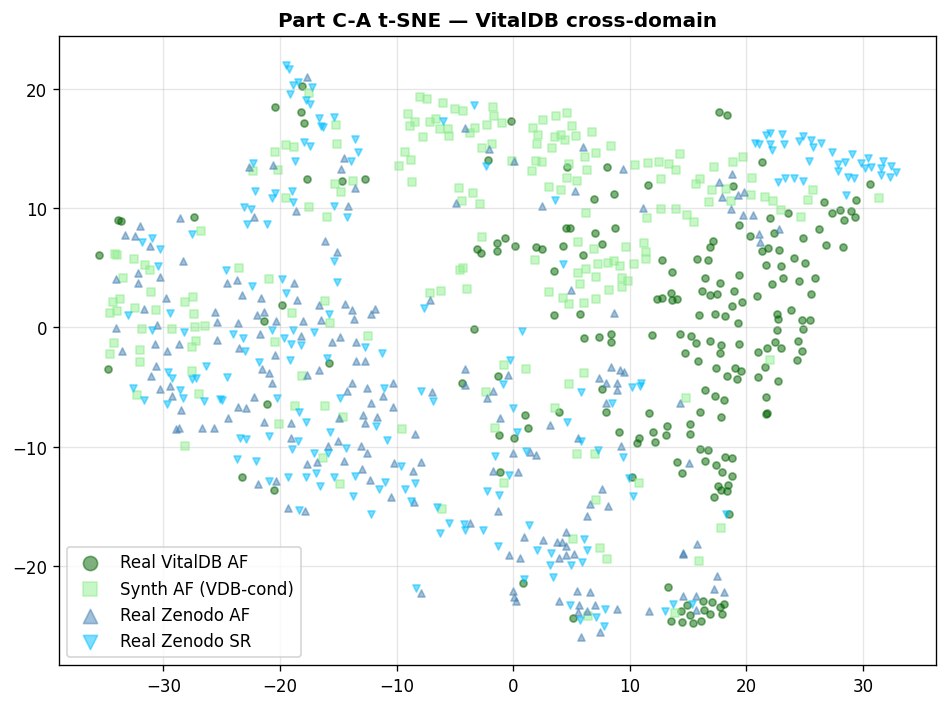

In [30]:
VITALDB_DIR=Path('/kaggle/input/datasets/vegatronxz/vitaldb-af-dataset/vitaldb_af_dataset')
ppg_vdb_raw=np.load(VITALDB_DIR/'ppg_windows.npy'); meta_vdb=pd.read_csv(VITALDB_DIR/'metadata_windows.csv')
def z_to_mm(sigs):
    out=np.empty_like(sigs)
    for i,sig in enumerate(sigs):
        mn,mx=sig.min(),sig.max(); out[i]=2*(sig-mn)/(mx-mn)-1 if mx-mn>1e-8 else np.zeros_like(sig)
    return out.astype(np.float32)
ppg_vdb_mm=z_to_mm(ppg_vdb_raw)
print(f'VitalDB AF: {ppg_vdb_mm.shape}  range=[{ppg_vdb_mm.min():.2f},{ppg_vdb_mm.max():.2f}]')
print(meta_vdb[['ibi_mean','ibi_std','rmssd']].describe().round(4).to_string())

nm_v,ns_v,nr_v=norm_ibi(meta_vdb['ibi_mean'].values,meta_vdb['ibi_std'].values,meta_vdb['rmssd'].values)
N_VG=min(3200,len(meta_vdb)); rng_v=np.random.default_rng(SEED); idx_v=rng_v.choice(len(meta_vdb),N_VG,replace=False)
cond_vt=torch.tensor(build_cond(nm_v[idx_v],ns_v[idx_v],nr_v[idx_v],np.full(len(idx_v),'AF')),dtype=torch.float32).to(DEVICE)
ppg_vdb_real_sub=ppg_vdb_mm[idx_v]
print(f'Generating {N_VG} VitalDB-conditioned synthetics...'); out_v=[]
for i in range(0,len(cond_vt),64): out_v.append(heun_sample(ema_model,cond_vt[i:i+64],ODE_STEPS,BEST_GS).cpu().numpy().squeeze(1))
ppg_vdb_synth=np.concatenate(out_v); print(f'Generated: {ppg_vdb_synth.shape}')

# Fidelity C-A
lsd_v=lsd(ppg_vdb_real_sub,ppg_vdb_synth); N_C=min(200,len(ppg_vdb_real_sub))
feat_v_r=feature_vec(ppg_vdb_real_sub[:N_C]); feat_v_s=feature_vec(ppg_vdb_synth[:N_C])
print(f'\nLSD (0.5-8 Hz): {lsd_v:.4f} dB  (in-domain: {lsd_mean:.4f} dB  MIMIC: {lsd_m:.4f} dB)')
wd_v_vals=[]
for i,fn in enumerate(feat_names):
    wdv=wasserstein_distance(feat_v_r[:,i],feat_v_s[:,i]); wd_v_vals.append(wdv)
    print(f'  {fn:<13}: {wdv:.4f}')
mmd_v=mmd_rbf(feat_v_r,feat_v_s,n=N_C); mmd_vxz=mmd_rbf(feat_v_r,feats['real_AF'],n=N_C)
dtw_v_fid,dtw_v_cov=dtw_nn_summary(ppg_vdb_real_sub,ppg_vdb_synth)
print(f'MMD²: {mmd_v:.6f}  domain-gap={mmd_vxz:.6f}'); print(f'DTW: fid={dtw_v_fid:.3f} cov={dtw_v_cov:.3f}')

N_T_C=min(200,N_C)
all_fc=np.concatenate([feat_v_r[:N_T_C],feat_v_s[:N_T_C],feats['real_AF'][:N_T_C],feats['real_SR'][:N_T_C]])
all_lc=['Real VitalDB AF']*N_T_C+['Synth AF (VDB-cond)']*N_T_C+['Real Zenodo AF']*N_T_C+['Real Zenodo SR']*N_T_C
sc_c=StandardScaler().fit_transform(all_fc); print('t-SNE C...')
emb_c=TSNE(n_components=2,perplexity=35,random_state=SEED,n_iter=1000).fit_transform(sc_c)
cmap_c={'Real VitalDB AF':('darkgreen','o'),'Synth AF (VDB-cond)':('lightgreen','s'),'Real Zenodo AF':('steelblue','^'),'Real Zenodo SR':('deepskyblue','v')}
fig,ax=plt.subplots(figsize=(8,6))
for lbl,(col,mrk) in cmap_c.items():
    mc=[l==lbl for l in all_lc]; ax.scatter(emb_c[mc,0],emb_c[mc,1],c=col,marker=mrk,alpha=0.5,s=18,label=lbl)
ax.set_title('Part C-A t-SNE — VitalDB cross-domain',fontweight='bold'); ax.legend(markerscale=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(WORK_DIR/'fig_partC_tsne.png',dpi=150); plt.show()


In [31]:
# ── Part C-B Classifier ──────────────────────────────────────────────────────
N_CU=min(len(ppg_vdb_synth),len(real_pool['AF']),len(real_pool['SR']))
rng_dc=np.random.default_rng(SEED+20); samp_c=lambda arr,n: arr[rng_dc.choice(len(arr),min(n,len(arr)),replace=False)]
N_HC=N_CU//2
dc1_X=np.vstack([samp_c(ppg_vdb_synth,N_CU),samp_c(real_pool['SR'],N_CU)]); dc1_y=np.array([1]*N_CU+[0]*N_CU)
dc2_X=np.vstack([samp_c(ppg_vdb_synth,N_HC),samp_c(real_pool['AF'],N_HC),samp_c(real_pool['SR'],N_CU)]); dc2_y=np.array([1]*N_HC+[1]*N_HC+[0]*N_CU)
dcref_X=np.vstack([samp_c(real_pool['AF'],N_CU),samp_c(real_pool['SR'],N_CU)]); dcref_y=np.array([1]*N_CU+[0]*N_CU)
datasets_C={'DC1 — VDB-synth AF + Zenodo SR':(dc1_X,dc1_y),'DC2 — VDB-synth AF + Zenodo AF + Zenodo SR (mix)':(dc2_X,dc2_y),'DCref — real Zenodo AF + real Zenodo SR (baseline)':(dcref_X,dcref_y)}
N_XC=min(len(ppg_vdb_mm),int((y_te==0).sum())); rng_xc=np.random.default_rng(SEED+30)
idx_vaf=rng_xc.choice(len(ppg_vdb_mm),N_XC,replace=False); idx_zsr2=rng_xc.choice(np.where(y_te==0)[0],N_XC,replace=False)
X_xdom_C=np.vstack([ppg_vdb_mm[idx_vaf],X_te[idx_zsr2]]); y_xdom_C=np.array([1]*N_XC+[0]*N_XC)
print(f'Cross-domain test C: VDB AF={N_XC}  Zenodo SR={N_XC}')
res_C_zen={}; res_C_xd={}
for ds,(Xtr_d,ytr_d) in datasets_C.items():
    print(f'\n{ds}'); ml_z={k:[] for k in ['accuracy','auroc','precision','recall','sensitivity','specificity','f1','threshold']}; ml_x={k:[] for k in ml_z}
    for s in range(5):
        torch.manual_seed(s); np.random.seed(s)
        clf,thr=train_unetgan(Xtr_d,ytr_d,X_vl,y_vl)
        mz=eval_unetgan(clf,X_te,y_te,thr); mz['threshold']=thr
        mx=eval_unetgan(clf,X_xdom_C,y_xdom_C,thr); mx['threshold']=thr
        for k in ml_z: ml_z[k].append(mz[k])
        for k in ml_x: ml_x[k].append(mx[k])
        print(f'  seed {s}  [Zenodo] AUROC={mz["auroc"]:.4f}  [XDom] AUROC={mx["auroc"]:.4f}')
    res_C_zen[ds]={k:(float(np.mean(v)),float(np.std(v))) for k,v in ml_z.items()}
    res_C_xd[ds]={k:(float(np.mean(v)),float(np.std(v))) for k,v in ml_x.items()}

print_table(res_C_zen,'Part C-B [Test 1: Zenodo v2 real test] — VDB-conditioned ClfUNetGAN')
print_table(res_C_xd, 'Part C-B [Test 2: Cross-domain — VitalDB AF + Zenodo SR]')


Cross-domain test C: VDB AF=2400  Zenodo SR=2400

DC1 — VDB-synth AF + Zenodo SR
  seed 0  [Zenodo] AUROC=0.4894  [XDom] AUROC=0.8914
  seed 1  [Zenodo] AUROC=0.4673  [XDom] AUROC=0.8462
  seed 2  [Zenodo] AUROC=0.4789  [XDom] AUROC=0.8924
  seed 3  [Zenodo] AUROC=0.4635  [XDom] AUROC=0.8902
  seed 4  [Zenodo] AUROC=0.4416  [XDom] AUROC=0.7481

DC2 — VDB-synth AF + Zenodo AF + Zenodo SR (mix)
  seed 0  [Zenodo] AUROC=0.4772  [XDom] AUROC=0.8939
  seed 1  [Zenodo] AUROC=0.5452  [XDom] AUROC=0.8561
  seed 2  [Zenodo] AUROC=0.4860  [XDom] AUROC=0.8915
  seed 3  [Zenodo] AUROC=0.4613  [XDom] AUROC=0.8890
  seed 4  [Zenodo] AUROC=0.4762  [XDom] AUROC=0.8940

DCref — real Zenodo AF + real Zenodo SR (baseline)
  seed 0  [Zenodo] AUROC=0.4752  [XDom] AUROC=0.8951
  seed 1  [Zenodo] AUROC=0.4988  [XDom] AUROC=0.8890
  seed 2  [Zenodo] AUROC=0.4796  [XDom] AUROC=0.8928
  seed 3  [Zenodo] AUROC=0.4653  [XDom] AUROC=0.8959
  seed 4  [Zenodo] AUROC=0.4212  [XDom] AUROC=0.3792

  Part C-B [Test 1: Z

## Part D: Cross-Domain FV — MIMIC-III-Ext-PPG

**Data source:** `ibi_session_3_380.csv` — pre-computed IBI features + WFDB paths  
**Format:** `IBI_mean, IBI_std, RMSSD, event_rhythm, wfdb_path, sub_win, subject_id`  
**PPG loading:** via `wfdb.rdrecord` → PLETH channel → bandpass → min-max [−1,1]  
**Conditioning norm:** Zenodo v2 training stats (same as Parts B and C)

**Datasets for ClfUNetGAN:**  
| Dataset | Training data |  
|---------|---------------|  
| DD1 | 100% MIMIC3-synth AF + 100% real Zenodo SR |  
| DD2 | 50% MIMIC3-synth AF + 50% real Zenodo AF + 100% real Zenodo SR |  
| DDref | 100% real Zenodo AF + 100% real Zenodo SR (baseline) |  


In [32]:
import wfdb

# ── Configure paths ───────────────────────────────────────────────────────────
MIMIC3_IBI_CSV  = Path('/kaggle/input/datasets/simaosoares4/ibi-values-b2/ibi_session_3_380.csv')
MIMIC3_DATA_DIR = Path('/kaggle/input/datasets/simaosoares4/mimic-ext-experiment/p00_380/p00')   # ← adjust if needed
MIMIC3_NPZ      = WORK_DIR / 'mimic3_ext_windows_for_zenodo.npz'
MIMIC3_IBI_OUT  = WORK_DIR / 'mimic3_ext_ibi_for_zenodo.csv'

# ── PPG loader (WFDB PLETH → bandpass → min-max) ─────────────────────────────
def load_mimic3_ppg(wfdb_path, sub_win, win_len=WIN_LEN, fs=FS):
    try:
        rec = wfdb.rdrecord(str(wfdb_path))
        sig_names = [s.lower() for s in (rec.sig_name or [])]
        ppg_idx = next((i for i,n in enumerate(sig_names)
                        if 'pleth' in n or 'ppg' in n), None)
        if ppg_idx is None: return None
        sig = rec.p_signal[:, ppg_idx].astype(np.float32)
        start = int(sub_win) * win_len; end = start + win_len
        if end > len(sig): return None
        win = sig[start:end]
        if len(win) < win_len or np.isnan(win).any() or np.all(win==win[0]): return None
        b,a = butter(4,[0.5/(fs/2),8./(fs/2)],btype='band'); win = filtfilt(b,a,win)
        mn,mx = win.min(),win.max()
        if mx-mn < 1e-8: return None
        return (2*(win-mn)/(mx-mn)-1).astype(np.float32)
    except: return None

# ── Load or build MIMIC-III-Ext window cache ─────────────────────────────────
if MIMIC3_NPZ.exists() and MIMIC3_IBI_OUT.exists():
    print('Loading MIMIC-III-Ext cache...')
    ppg_m3_af = np.load(MIMIC3_NPZ)['signals']
    meta_m3   = pd.read_csv(MIMIC3_IBI_OUT)
else:
    print('Loading MIMIC-III-Ext IBI CSV...')
    df_m3 = pd.read_csv(MIMIC3_IBI_CSV)
    print(f'  Total rows: {len(df_m3)}')
    print(df_m3.columns.tolist())
    print(df_m3.head(2).to_string())

    # Filter to AF only + physiological plausibility
    df_m3_af = df_m3[
        (df_m3['event_rhythm'].str.upper() == 'AF') &
        df_m3['IBI_mean'].between(IBI_MIN, IBI_MAX) &
        df_m3['IBI_std'].gt(0) &
        df_m3['RMSSD'].gt(0)
    ].copy().reset_index(drop=True)
    print(f'  AF windows with valid IBI: {len(df_m3_af)}')

    print('Loading PPG windows from WFDB...')
    sigs_m3 = []
    valid_rows = []
    for i, (_, row) in enumerate(df_m3_af.iterrows()):
        if i % 500 == 0 and i > 0: print(f'  {i}/{len(df_m3_af)}')
        wfdb_path = MIMIC3_DATA_DIR / row['wfdb_path']
        sig = load_mimic3_ppg(wfdb_path, row.get('sub_win', 0))
        if sig is None: continue
        sigs_m3.append(sig); valid_rows.append(row)

    ppg_m3_af = np.array(sigs_m3, dtype=np.float32)
    meta_m3   = pd.DataFrame(valid_rows).reset_index(drop=True)
    np.savez_compressed(MIMIC3_NPZ, signals=ppg_m3_af)
    meta_m3.to_csv(MIMIC3_IBI_OUT, index=False)
    print(f'  Cached {ppg_m3_af.shape[0]} MIMIC-III-Ext AF windows')

print(f'\nMIMIC-III-Ext AF windows: {ppg_m3_af.shape}')
print(meta_m3[['IBI_mean','IBI_std','RMSSD']].describe().round(4).to_string())


Loading MIMIC-III-Ext IBI CSV...
  Total rows: 196653
['signal_file_name', 'sub_win', 'subject_id', 'event_rhythm', 'wfdb_path', 'IBI_mean', 'IBI_std', 'RMSSD', 'source']
    signal_file_name  sub_win  subject_id event_rhythm                                                                                       wfdb_path  IBI_mean   IBI_std     RMSSD source
0  3533390_0011_6_17        2          52           SR  /kaggle/input/datasets/simaosoares4/mimic-ext-experiment/p00_350/p00/p000052/3533390_0011_6_17  0.693538  0.013083  0.020133    ecg
1   3533390_0011_0_9        0          52           SR   /kaggle/input/datasets/simaosoares4/mimic-ext-experiment/p00_350/p00/p000052/3533390_0011_0_9  0.678857  0.013130  0.009148    ecg
  AF windows with valid IBI: 98670
Loading PPG windows from WFDB...
  500/98670
  1000/98670
  1500/98670
  2000/98670
  2500/98670
  3000/98670
  3500/98670
  4000/98670
  4500/98670
  5000/98670
  5500/98670
  6000/98670
  6500/98670
  7000/98670
  7500/98670
  8

Generating 3200 MIMIC-III-Ext-conditioned synthetics (Zenodo model)...
Generated: (3200, 1250)  range=[-1.209,1.167]

LSD (0.5–8 Hz): 7.3515 dB  (in-domain: 8.1116  MIMIC-AF: 6.5721  VDB: 8.0553)
  HR_mean      : 4.5117
  HR_std       : 7.8099
  Power_0-4Hz  : 0.0214
  Power_4-8Hz  : 0.0015
  RMS          : 0.0428
MMD²: 0.061679  domain-gap=0.179762
DTW: 3.724±0.377
t-SNE D...


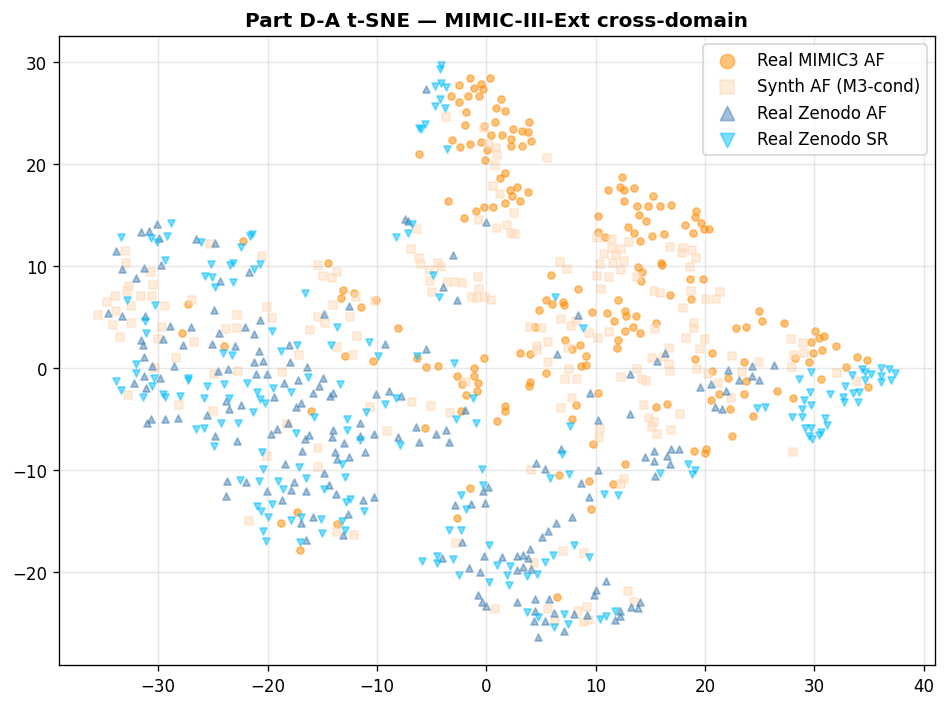

In [33]:
# ── Generate MIMIC-III-Ext-conditioned synthetics ────────────────────────────
# Column names from ibi_session CSV may be IBI_mean/IBI_std/RMSSD (capitalised)
ibi_m_col = 'IBI_mean' if 'IBI_mean' in meta_m3.columns else 'ibi_mean'
ibi_s_col = 'IBI_std'  if 'IBI_std'  in meta_m3.columns else 'ibi_std'
rmssd_col = 'RMSSD'    if 'RMSSD'    in meta_m3.columns else 'rmssd'

nm_3,ns_3,nr_3 = norm_ibi(meta_m3[ibi_m_col].values, meta_m3[ibi_s_col].values, meta_m3[rmssd_col].values)
N_M3G = min(3200, len(meta_m3)); rng_m3 = np.random.default_rng(SEED)
idx_m3 = rng_m3.choice(len(meta_m3), N_M3G, replace=False)
cond_m3t = torch.tensor(build_cond(nm_3[idx_m3],ns_3[idx_m3],nr_3[idx_m3],np.full(len(idx_m3),'AF')),
                         dtype=torch.float32).to(DEVICE)
ppg_m3_real_sub = ppg_m3_af[idx_m3]

print(f'Generating {N_M3G} MIMIC-III-Ext-conditioned synthetics (Zenodo model)...')
out_m3 = []
for i in range(0, len(cond_m3t), 64):
    out_m3.append(heun_sample(ema_model, cond_m3t[i:i+64], ODE_STEPS, BEST_GS).cpu().numpy().squeeze(1))
ppg_m3_synth = np.concatenate(out_m3)
print(f'Generated: {ppg_m3_synth.shape}  range=[{ppg_m3_synth.min():.3f},{ppg_m3_synth.max():.3f}]')

# ── Part D-A Fidelity ────────────────────────────────────────────────────────
lsd_d = lsd(ppg_m3_real_sub, ppg_m3_synth)
N_D   = min(200, len(ppg_m3_real_sub))
feat_d_r = feature_vec(ppg_m3_real_sub[:N_D]); feat_d_s = feature_vec(ppg_m3_synth[:N_D])
print(f'\nLSD (0.5–8 Hz): {lsd_d:.4f} dB  (in-domain: {lsd_mean:.4f}  MIMIC-AF: {lsd_m:.4f}  VDB: {lsd_v:.4f})')
wd_d_vals=[]
for i,fn in enumerate(feat_names):
    wdd=wasserstein_distance(feat_d_r[:,i],feat_d_s[:,i]); wd_d_vals.append(wdd)
    print(f'  {fn:<13}: {wdd:.4f}')
mmd_d=mmd_rbf(feat_d_r,feat_d_s,n=N_D); mmd_dxz=mmd_rbf(feat_d_r,feats['real_AF'],n=N_D)
dtw_d_fid,dtw_d_cov=dtw_nn_summary(ppg_m3_real_sub,ppg_m3_synth)
print(f'MMD²: {mmd_d:.6f}  domain-gap={mmd_dxz:.6f}')
print(f'DTW: fid={dtw_d_fid:.3f} cov={dtw_d_cov:.3f}')

N_T_D=min(200,N_D)
all_fd=np.concatenate([feat_d_r[:N_T_D],feat_d_s[:N_T_D],feats['real_AF'][:N_T_D],feats['real_SR'][:N_T_D]])
all_ld=['Real MIMIC3 AF']*N_T_D+['Synth AF (M3-cond)']*N_T_D+['Real Zenodo AF']*N_T_D+['Real Zenodo SR']*N_T_D
sc_d=StandardScaler().fit_transform(all_fd); print('t-SNE D...')
emb_d=TSNE(n_components=2,perplexity=35,random_state=SEED,n_iter=1000).fit_transform(sc_d)
cmap_d={'Real MIMIC3 AF':('darkorange','o'),'Synth AF (M3-cond)':('peachpuff','s'),'Real Zenodo AF':('steelblue','^'),'Real Zenodo SR':('deepskyblue','v')}
fig,ax=plt.subplots(figsize=(8,6))
for lbl,(col,mrk) in cmap_d.items():
    md_mask=[l==lbl for l in all_ld]; ax.scatter(emb_d[md_mask,0],emb_d[md_mask,1],c=col,marker=mrk,alpha=0.5,s=18,label=lbl)
ax.set_title('Part D-A t-SNE — MIMIC-III-Ext cross-domain',fontweight='bold'); ax.legend(markerscale=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(WORK_DIR/'fig_partD_tsne.png',dpi=150); plt.show()


In [34]:
# ── Part D-B Classifier ──────────────────────────────────────────────────────
N_DU=min(len(ppg_m3_synth),len(real_pool['AF']),len(real_pool['SR']))
rng_dd=np.random.default_rng(SEED+20); samp_d=lambda arr,n: arr[rng_dd.choice(len(arr),min(n,len(arr)),replace=False)]
N_HD=N_DU//2
dd1_X=np.vstack([samp_d(ppg_m3_synth,N_DU),samp_d(real_pool['SR'],N_DU)]); dd1_y=np.array([1]*N_DU+[0]*N_DU)
dd2_X=np.vstack([samp_d(ppg_m3_synth,N_HD),samp_d(real_pool['AF'],N_HD),samp_d(real_pool['SR'],N_DU)]); dd2_y=np.array([1]*N_HD+[1]*N_HD+[0]*N_DU)
ddref_X=np.vstack([samp_d(real_pool['AF'],N_DU),samp_d(real_pool['SR'],N_DU)]); ddref_y=np.array([1]*N_DU+[0]*N_DU)
datasets_D={'DD1 — MIMIC3-synth AF + Zenodo SR':(dd1_X,dd1_y),'DD2 — MIMIC3-synth AF + Zenodo AF + Zenodo SR (mix)':(dd2_X,dd2_y),'DDref — real Zenodo AF + real Zenodo SR (baseline)':(ddref_X,ddref_y)}
N_XD=min(len(ppg_m3_af),int((y_te==0).sum())); rng_xd2=np.random.default_rng(SEED+30)
idx_m3af=rng_xd2.choice(len(ppg_m3_af),N_XD,replace=False); idx_zsr3=rng_xd2.choice(np.where(y_te==0)[0],N_XD,replace=False)
X_xdom_D=np.vstack([ppg_m3_af[idx_m3af],X_te[idx_zsr3]]); y_xdom_D=np.array([1]*N_XD+[0]*N_XD)
print(f'Cross-domain test D: MIMIC3 AF={N_XD}  Zenodo SR={N_XD}')
res_D_zen={}; res_D_xd={}
for ds,(Xtr_d,ytr_d) in datasets_D.items():
    print(f'\n{ds}'); ml_z={k:[] for k in ['accuracy','auroc','precision','recall','sensitivity','specificity','f1','threshold']}; ml_x={k:[] for k in ml_z}
    for s in range(5):
        torch.manual_seed(s); np.random.seed(s)
        clf,thr=train_unetgan(Xtr_d,ytr_d,X_vl,y_vl)
        mz=eval_unetgan(clf,X_te,y_te,thr); mz['threshold']=thr
        mx=eval_unetgan(clf,X_xdom_D,y_xdom_D,thr); mx['threshold']=thr
        for k in ml_z: ml_z[k].append(mz[k])
        for k in ml_x: ml_x[k].append(mx[k])
        print(f'  seed {s}  [Zenodo] AUROC={mz["auroc"]:.4f}  [XDom] AUROC={mx["auroc"]:.4f}')
    res_D_zen[ds]={k:(float(np.mean(v)),float(np.std(v))) for k,v in ml_z.items()}
    res_D_xd[ds]={k:(float(np.mean(v)),float(np.std(v))) for k,v in ml_x.items()}

print_table(res_D_zen,'Part D-B [Test 1: Zenodo v2 real test] — MIMIC3-conditioned ClfUNetGAN')
print_table(res_D_xd, 'Part D-B [Test 2: Cross-domain — MIMIC3 AF + Zenodo SR]')


Cross-domain test D: MIMIC3 AF=2400  Zenodo SR=2400

DD1 — MIMIC3-synth AF + Zenodo SR
  seed 0  [Zenodo] AUROC=0.4905  [XDom] AUROC=0.7386
  seed 1  [Zenodo] AUROC=0.4249  [XDom] AUROC=0.7328
  seed 2  [Zenodo] AUROC=0.4271  [XDom] AUROC=0.5133
  seed 3  [Zenodo] AUROC=0.4230  [XDom] AUROC=0.5727
  seed 4  [Zenodo] AUROC=0.5008  [XDom] AUROC=0.1930

DD2 — MIMIC3-synth AF + Zenodo AF + Zenodo SR (mix)
  seed 0  [Zenodo] AUROC=0.4771  [XDom] AUROC=0.7558
  seed 1  [Zenodo] AUROC=0.4423  [XDom] AUROC=0.6950
  seed 2  [Zenodo] AUROC=0.4690  [XDom] AUROC=0.7593
  seed 3  [Zenodo] AUROC=0.4632  [XDom] AUROC=0.7594
  seed 4  [Zenodo] AUROC=0.4506  [XDom] AUROC=0.3375

DDref — real Zenodo AF + real Zenodo SR (baseline)
  seed 0  [Zenodo] AUROC=0.5189  [XDom] AUROC=0.7161
  seed 1  [Zenodo] AUROC=0.4996  [XDom] AUROC=0.7301
  seed 2  [Zenodo] AUROC=0.4797  [XDom] AUROC=0.7641
  seed 3  [Zenodo] AUROC=0.4701  [XDom] AUROC=0.7958
  seed 4  [Zenodo] AUROC=0.4224  [XDom] AUROC=0.4349

  Part D-B [

### §13 — Data scarcity experiment
Vary number of Cat A (AF) subjects in training (1→17). Cat B SR subjects always included. Measure AUROC for TRTR and TSTR for both Clf1D and ClfUNetGAN.

In [ ]:
# ── §11d — Data Scarcity (Clf1D × ClfUNetGAN, DDIM × Ancestral) ──────────────
# Aproximação por fração de TRAIN_A (sem subject_id por janela no df_train —
# ver nota de metodologia): N subjects ≈ N/len(TRAIN_A) do pool de AF.
N_VALUES = [4, 8, 10, 12, 16]
N_SEEDS_SCAR = 5
N_CAT_A = len(TRAIN_A)

real_af_all  = X_tr_r[y_tr_r==1]
real_sr_all  = X_tr_r[y_tr_r==0]   # SR sempre real e completo (fixed)

print(f'Data Scarcity — N_CAT_A={N_CAT_A}  N_VALUES={N_VALUES}  seeds={N_SEEDS_SCAR}')
print(f'Real AF pool: {len(real_af_all)}   Real SR pool (fixo): {len(real_sr_all)}\n')

CLASSIFIERS = [('Clf1D', train_unetgan, eval_unetgan), ('ClfUNetGAN', train_unetgan, eval_unetgan)]
SAMPLERS    = ['ddim', 'ancs']

# ── Referência full-data (TRTR), independente de N e do sampler ──────────────
ref_full = {}
for clf_name, train_fn, eval_fn in CLASSIFIERS:
    aurocs = []
    for s in range(N_SEEDS_SCAR):
        torch.manual_seed(s); np.random.seed(s)
        clf, thr = train_fn(X_tr, y_tr, X_vl, y_vl)
        aurocs.append(eval_fn(clf, X_te, y_te, thr)['auroc'])
    ref_full[clf_name] = float(np.mean(aurocs))
    print(f'  REF full-data {clf_name}: AUROC={ref_full[clf_name]:.4f}')

# ── Loop principal ────────────────────────────────────────────────────────────
scar_results = {}  # {clf_name: {sampler: {N: {'TRTR':.., 'TSTR':.., 'ClfB':..}}}}

for clf_name, train_fn, eval_fn in CLASSIFIERS:
    scar_results[clf_name] = {}
    print(f'\n{"="*90}\n  {clf_name}\n{"="*90}')
    for samp in SAMPLERS:
        synth_af_all = synth_train[samp]['AF']
        scar_results[clf_name][samp] = {}
        print(f'\n  ── sampler={samp} ' + '─'*60)
        for N in N_VALUES:
            frac = N / N_CAT_A
            n_real_af  = max(10, int(len(real_af_all)  * frac))
            n_synth_af = max(10, int(len(synth_af_all) * frac))
            n_sr       = min(len(real_sr_all), n_real_af)

            auroc_trtr, auroc_tstr, auroc_clfb = [], [], []
            for seed in range(N_SEEDS_SCAR):
                rng_s = np.random.default_rng(seed*1000 + N)
                idx_raf = rng_s.choice(len(real_af_all),  n_real_af,  replace=False)
                idx_saf = rng_s.choice(len(synth_af_all), n_synth_af, replace=False)
                idx_sr  = rng_s.choice(len(real_sr_all),  n_sr,       replace=False)

                Xtr_TRTR = np.vstack([real_af_all[idx_raf],  real_sr_all[idx_sr]])
                ytr_TRTR = np.array([1]*n_real_af + [0]*n_sr)
                Xtr_TSTR = np.vstack([synth_af_all[idx_saf], real_sr_all[idx_sr]])
                ytr_TSTR = np.array([1]*n_synth_af + [0]*n_sr)
                n_sr_b   = min(len(real_sr_all), n_real_af + n_synth_af)
                idx_sr_b = rng_s.choice(len(real_sr_all), n_sr_b, replace=False)
                Xtr_ClfB = np.vstack([real_af_all[idx_raf], synth_af_all[idx_saf], real_sr_all[idx_sr_b]])
                ytr_ClfB = np.array([1]*n_real_af + [1]*n_synth_af + [0]*n_sr_b)

                for tag, Xtr_c, ytr_c, bucket in [('TRTR',Xtr_TRTR,ytr_TRTR,auroc_trtr),
                                                    ('TSTR',Xtr_TSTR,ytr_TSTR,auroc_tstr),
                                                    ('ClfB',Xtr_ClfB,ytr_ClfB,auroc_clfb)]:
                    torch.manual_seed(seed); np.random.seed(seed)
                    clf, thr = train_fn(Xtr_c, ytr_c, X_vl, y_vl)
                    bucket.append(eval_fn(clf, X_te, y_te, thr)['auroc'])

            scar_results[clf_name][samp][N] = {
                'TRTR': (float(np.mean(auroc_trtr)), float(np.std(auroc_trtr))),
                'TSTR': (float(np.mean(auroc_tstr)), float(np.std(auroc_tstr))),
                'ClfB': (float(np.mean(auroc_clfb)), float(np.std(auroc_clfb))),
            }
            r = scar_results[clf_name][samp][N]
            print(f'    N≈{N:2d} subj (frac={frac:.2f}, n_AF_real={n_real_af}, n_AF_synth={n_synth_af})  '
                  f'TRTR={r["TRTR"][0]:.4f}  TSTR={r["TSTR"][0]:.4f}  ClfB={r["ClfB"][0]:.4f}')

# ── Tabelas finais ────────────────────────────────────────────────────────────
for clf_name in scar_results:
    print(f'\n{"="*95}\n  §11d — Data Scarcity — {clf_name}  (ref full-data AUROC={ref_full[clf_name]:.4f})\n{"="*95}')
    for samp in SAMPLERS:
        print(f'\n  sampler={samp}')
        print(f"  {'N':>5}  {'TRTR':>18}  {'TSTR':>18}  {'ClfB':>18}")
        print('  ' + '─'*68)
        for N in N_VALUES:
            r = scar_results[clf_name][samp][N]
            print(f"  {N:>5}  {r['TRTR'][0]:.4f}±{r['TRTR'][1]:.3f}     "
                  f"{r['TSTR'][0]:.4f}±{r['TSTR'][1]:.3f}     "
                  f"{r['ClfB'][0]:.4f}±{r['ClfB'][1]:.3f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for row, clf_name in enumerate(scar_results):
    for col, samp in enumerate(SAMPLERS):
        ax = axes[row, col]
        for tag, col_c, ls in [('TRTR','steelblue','-'),('TSTR','crimson','--'),('ClfB','seagreen',':')]:
            mu = [scar_results[clf_name][samp][N][tag][0] for N in N_VALUES]
            sd = [scar_results[clf_name][samp][N][tag][1] for N in N_VALUES]
            ax.plot(N_VALUES, mu, color=col_c, ls=ls, lw=2, label=tag)
            ax.fill_between(N_VALUES, np.array(mu)-np.array(sd), np.array(mu)+np.array(sd), alpha=0.15, color=col_c)
        ax.axhline(ref_full[clf_name], color='gray', ls='-.', lw=1, label='Full-data ref')
        ax.set_title(f'{clf_name} — {samp}'); ax.set_xlabel('N subjects (aprox.)'); ax.set_ylabel('AUROC')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('Zenodo v2 DDPM — Data Scarcity Experiment', fontweight='bold')
plt.tight_layout(); plt.savefig(WORK_DIR / 'fig_scarcity_ddpm.png', dpi=150); plt.show()

## §14 — Complete Results Summary

In [35]:
print("="*70)
print("  ZENODO v2 OT-CFM B2 — COMPLETE RESULTS SUMMARY")
print("="*70)
print(f"  Model: UNet1D base_ch={BASE_CH}  4 levels  AdaGN  Heun gs={BEST_GS}")
print(f"  Best val loss: {ckpt['val_loss']:.4f}  Train windows: {len(df_train['rhythm'])}")
print()
print("  ── §8  Spectral ──────────────────────────────────────────────")
print(f"  LSD AF={lsd_af:.4f}  LSD SR={lsd_sr:.4f}  mean={lsd_mean:.4f} dB")
print()
print("  ── §10 Statistical ───────────────────────────────────────────")
print(f"  MMD² AF={mmd_af:.6f}  SR={mmd_sr:.6f}")
print(f"  DTW  AF={dtw_af_m:.3f}±{dtw_af_s:.3f}  SR={dtw_sr_m:.3f}±{dtw_sr_s:.3f}")
print()
print("  ── §10c Conditioning Fidelity (paired AF) ────────────────────")
print(f"  Peak detection rate: {fid['peak_rate']:.1f}%")
print(f"  MAE HR: {fid['mae_hr']:.3f} bpm  IBI_std ratio: {fid['ibi_std_ratio']:.3f}  Pearson HR: {fid['pearson_hr']:.4f}")
print()
print("  ── §11a Clf1D Functional Evaluation ─────────────────────────")
for c,m in results11a.items():
    print(f"  {c:<6}: AUROC={m['auroc'][0]:.4f}±{m['auroc'][1]:.4f}  F1={m['f1'][0]:.4f}±{m['f1'][1]:.4f}")
print()
print("  ── §11b Baseline (unconditioned) ─────────────────────────────")
print(f"  TSTR conditioned={results11a['TSTR']['auroc'][0]:.4f}  unconditioned={m_base['auroc']:.4f}  gain={results11a['TSTR']['auroc'][0]-m_base['auroc']:+.4f}")
print()
print("  ── Cross-Domain Summary (Parts B / C / D) ────────────────────")
print(f"  {'Dataset':<50}  {'[Zenodo]':>9}  {'[XDom]':>9}")
print("  "+"─"*72)
for tag,rz,rx in [('B',res_B_zen,res_B_xd),('C',res_C_zen,res_C_xd),('D',res_D_zen,res_D_xd)]:
    for ds in rz:
        print(f"  {tag}: {ds:<46}  {rz[ds]['auroc'][0]:>9.4f}  {rx[ds]['auroc'][0]:>9.4f}")
print("="*70)


  ZENODO v2 OT-CFM B2 — COMPLETE RESULTS SUMMARY
  Model: UNet1D base_ch=64  4 levels  AdaGN  Heun gs=2.0
  Best val loss: 0.1102  Train windows: 30426

  ── §8  Spectral ──────────────────────────────────────────────
  LSD AF=7.7428  LSD SR=8.4804  mean=8.1116 dB

  ── §10 Statistical ───────────────────────────────────────────
  MMD² AF=0.010731  SR=0.001776
  DTW  AF=4.107±1.519  SR=3.715±1.040

  ── §10c Conditioning Fidelity (paired AF) ────────────────────
  Peak detection rate: 100.0%
  MAE HR: 25.156 bpm  IBI_std ratio: 0.957  Pearson HR: 0.3438

  ── §11a Clf1D Functional Evaluation ─────────────────────────
  TRTR  : AUROC=0.7002±0.0162  F1=0.4367±0.0255
  TSTR  : AUROC=0.6885±0.0183  F1=0.4561±0.0188
  ClfB  : AUROC=0.7139±0.0043  F1=0.4563±0.0070

  ── §11b Baseline (unconditioned) ─────────────────────────────
  TSTR conditioned=0.6885  unconditioned=0.5539  gain=+0.1346

  ── Cross-Domain Summary (Parts B / C / D) ────────────────────
  Dataset                            